# TCC · Análise integrada dos alagamentos de São Paulo por subprefeitura
**Henrique Nascimento Santos · Consolidação da EDA das estações + baseline D+1 + GeoSampa · Setembro/2026**

**Atualização v2:** as seções 1–3 preservam os experimentos MUNICIPAIS anteriores; a seção 4 requer observações individuais reais do CEMADEN para gerar novas métricas. Nenhuma AP anterior deve ser rotulada como resultado de chuva regionalizada.

Este caderno substitui a navegação entre `EDA_completa_estacoes_SP_1.ipynb` e `02_Modelagem_Baseline_Alagamentos_Dia_Seguinte.ipynb`. A pergunta ampliada é: **as características territoriais agregam informação à meteorologia para estimar a ocorrência de registros de alagamento em cada subprefeitura?**

**Ordem:** (1) inventário, datas, qualidade e representatividade espacial; (2) análise de variáveis e associação regional; (3) baseline municipal e experimentos de Machine Learning no painel região-dia. Todos os arquivos de entrada são somente lidos. Resultados e figuras são exportados para uma pasta separada.

**Interpretação:** `1` significa registro do CGE, não ocorrência física exaustivamente confirmada; `0` é ausência de registro na base. O inventário GeoSampa é um retrato de anos distintos e não deve ser tratado como histórico urbano ano a ano. A precipitação atualmente disponível nos CSVs é **municipal**: sem as observações diárias por estação, este caderno **não** inventa chuva local por subprefeitura.

## 0 · Ambiente, arquivos e protocolo

Execute da raiz do projeto ou diretamente da pasta `scripts/análises` no VS Code. A célula abaixo também reconhece a pasta de arquivos anexados a esta conversa para permitir reproduzir o experimento sem cópias manuais. Pacotes: `pandas`, `numpy`, `matplotlib`, `scipy`, `scikit-learn`, `geopandas`, `IPython`. Os scripts originais e os CSVs não são modificados.

**Protocolo de avaliação:** alvo no dia `t+1`; variáveis meteorológicas somente até o encerramento do dia `t`; treino com alvos até 2021, validação em 2022–2023 e teste reservado em 2024–maio/2026, com separação de fronteira temporal. O estudo territorial é retrospectivo, pois a camada de drenagem cadastrada em 2026 não estava comprovadamente disponível nos anos anteriores.

In [1]:
from pathlib import Path
import hashlib, json, platform
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, accuracy_score, brier_score_loss, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay)

SEMENTE = 42
plt.rcParams.update({'figure.dpi':105, 'axes.spines.top':False,
                     'axes.spines.right':False, 'axes.grid':True,'grid.alpha':.16})
CAMINHO_ATUAL = Path.cwd().resolve()
CANDIDATOS = [CAMINHO_ATUAL, *CAMINHO_ATUAL.parents]
RAIZ = next((p for p in CANDIDATOS
             if (p / 'data/outputs/datasets/dataset_final_integrado.csv').exists()
             and (p / 'data/outputs/geosampa/indicadores_subprefeituras.csv').exists()), None)
if RAIZ is None and (Path('/mnt/data') / 'dataset_final_integrado.csv').exists():
    RAIZ = Path('/mnt/data')
if RAIZ is None:
    raise FileNotFoundError('Não encontrei data/outputs/datasets e data/outputs/geosampa. Execute na raiz do projeto.')
ANEXO = RAIZ == Path('/mnt/data')
DADOS = RAIZ if ANEXO else RAIZ / 'data/outputs/datasets'
GEO = RAIZ if ANEXO else RAIZ / 'data/outputs/geosampa'
SAIDA = (RAIZ / 'resultados_analise_integrada' if ANEXO
         else RAIZ / 'data/outputs/modelagem/analise_integrada_subprefeituras')
SAIDA.mkdir(parents=True, exist_ok=True)

def carrega(nome, geo=False, **kwargs):
    return pd.read_csv((GEO if geo else DADOS) / nome, **kwargs)

def figura(nome):
    plt.tight_layout()
    plt.savefig(SAIDA / f'{nome}.png', bbox_inches='tight', dpi=135)
    plt.show()

print('Entradas:', DADOS, '| GeoSampa:', GEO, '| Saídas:', SAIDA)
print('Python:', platform.python_version())

Entradas: C:\Users\rickn\OneDrive\Documentos\GitHub\Projeto_Previsão_Alagamentos_TCC_2026\data\outputs\datasets | GeoSampa: C:\Users\rickn\OneDrive\Documentos\GitHub\Projeto_Previsão_Alagamentos_TCC_2026\data\outputs\geosampa | Saídas: C:\Users\rickn\OneDrive\Documentos\GitHub\Projeto_Previsão_Alagamentos_TCC_2026\data\outputs\modelagem\analise_integrada_subprefeituras
Python: 3.10.0


# 1 · Quais dados temos agora?

Nesta seção, distinguimos **escala original**, **janela temporal** e **data de referência da camada urbana**. Uma série diária municipal repetida em 32 linhas de um mesmo dia continua sendo informação meteorológica **municipal**; não se torna chuva local por causa do `merge`.

In [2]:
# Nunca carregar os códigos territoriais como números: '01' e '1' não são chaves equivalentes em exportações.
municipio = carrega('dataset_final_integrado.csv', parse_dates=['date']).sort_values('date')
cge_bruto = carrega('final_data.csv')
cge_bruto['date'] = pd.to_datetime(cge_bruto['date'], format='%d-%m-%Y', errors='raise')
painel_cge = carrega('cge_subprefeitura_dia.csv', geo=True,
                    dtype={'codigo_subprefeitura':str}, parse_dates=['date'])
urbano = carrega('indicadores_subprefeituras.csv', geo=True,
                dtype={'codigo_subprefeitura':str})
limites = gpd.read_file(GEO / 'subprefeituras_tratadas.gpkg')
limites['codigo_subprefeitura'] = limites['codigo_subprefeitura'].astype(str).str.zfill(2)
cemaden_estacoes = carrega('cemaden_estacoes.csv', dtype={'cod_estacao':str})
cemaden_diario = carrega('cemaden_sp_diario.csv', parse_dates=['date'])
inmet_estacoes = carrega('stations_metadata.csv', dtype={'codigo':str})
inmet_diario = carrega('consolidated_dataset.csv', parse_dates=['date'])
open_meteo = carrega('open_meteo_sp.csv', parse_dates=['date'])
previsoes_arquivo = carrega('open_meteo_previous_runs_sp.csv', parse_dates=['date'])
correspondencia = carrega('correspondencia_cge_subprefeituras.csv', geo=True,
                         dtype={'codigo_subprefeitura':str})
vegetacao_categorias = carrega('vegetacao_por_categoria.csv', geo=True,
                              dtype={'codigo_subprefeitura':str})
drenagem_tipos = carrega('drenagem_por_tipo.csv', geo=True,
                        dtype={'codigo_subprefeitura':str})
with open(GEO / 'auditoria.json', encoding='utf-8') as f: auditoria = json.load(f)
for df in [painel_cge, urbano, limites, correspondencia, vegetacao_categorias, drenagem_tipos]:
    df['codigo_subprefeitura'] = df['codigo_subprefeitura'].astype(str).str.zfill(2)
assert urbano.codigo_subprefeitura.nunique() == limites.codigo_subprefeitura.nunique() == 32
assert not municipio.date.duplicated().any()
assert not painel_cge.duplicated(['date','codigo_subprefeitura']).any()
assert len(painel_cge) == len(municipio) * 32
assert set(painel_cge.codigo_subprefeitura) == set(urbano.codigo_subprefeitura)
assert int(painel_cge.n_registros_cge.sum()) == int(municipio.n_events.sum())
assert (painel_cge.groupby('date').tem_registro_cge.max().to_numpy() ==
        municipio.set_index('date').loc[painel_cge.date.drop_duplicates().sort_values(), 'has_flooding'].to_numpy()).all()
print('Reconciliação CGE municipal/regional OK:', int(painel_cge.n_registros_cge.sum()), 'registros.')

Reconciliação CGE municipal/regional OK: 9397 registros.


In [3]:
def periodo(df):
    return f"{df.date.min():%d/%m/%Y} a {df.date.max():%d/%m/%Y}"
DATA_VEGETACAO = ', '.join(urbano.ano_voo_vegetacao.astype(str).unique())
DATA_DRENAGEM = ', '.join(urbano.atualizacao_cadastro_drenagem.astype(str).unique())
linhas_inventario = [
    ('CGE — registros originais','Evento / logradouro',periodo(cge_bruto),len(cge_bruto),'Somente registros; inclui linhas de calendário vazias e duplicatas preservadas.'),
    ('CGE — painel territorial','Subprefeitura × dia',periodo(painel_cge),len(painel_cge),'32 regiões; ausência de registro não prova ausência física de alagamento.'),
    ('CEMADEN — metadados','Estação / coordenadas','Rede disponível na extração',len(cemaden_estacoes),'Observações individuais diárias NÃO foram anexadas.'),
    ('CEMADEN — consolidado','Município × dia',periodo(cemaden_diario),len(cemaden_diario),'95 estações inventariadas; IDW calculado para o centro do município.'),
    ('INMET — metadados','Estação / coordenadas','Rede disponível na extração',len(inmet_estacoes),'Sem série individual por estação entre os anexos.'),
    ('INMET — consolidado','Município × dia',periodo(inmet_diario),len(inmet_diario),'Ponderação municipal; 14 estações inventariadas.'),
    ('Open-Meteo — histórico','Ponto central × dia',periodo(open_meteo),len(open_meteo),'Reanálise/reconstrução; disponibilidade em tempo real não comprovada.'),
    ('Open-Meteo — Previous Runs','Ponto central × dia-alvo',periodo(previsoes_arquivo),len(previsoes_arquivo),'Arquivos para D-1/D-2/D-3, apenas a partir de 2024; checar emissão.'),
    ('GeoSampa — vegetação','Polígonos → subprefeitura',f'Voo {DATA_VEGETACAO}',len(urbano),'Percentual de área mapeada, NÃO de permeabilidade.'),
    ('GeoSampa — drenagem','Linhas → subprefeitura',f'Cadastro {DATA_DRENAGEM}',len(urbano),'Extensão/densidade cadastrada, NÃO capacidade hidráulica.'),
    ('GeoSampa — limites','Polígonos de subprefeituras','Cadastro baixado em 2026',len(limites),'32 limites atuais; não equivalem necessariamente às fronteiras históricas.'),
]
inventario = pd.DataFrame(linhas_inventario,columns=['fonte','granularidade','periodo_ou_data','linhas','observacao'])
display(inventario)
print('Dias municipais com registro:', int(municipio.has_flooding.sum()))
print('Dias-região com registro:', int(painel_cge.tem_registro_cge.sum()))
print('Coleta CGE explicitamente confirmada:', int(painel_cge.coleta_confirmada.notna().sum()), 'linhas.')
print('Repetições CGE excedentes preservadas:', auditoria['cge']['duplicatas_excedentes_preservadas'])
inventario.to_csv(SAIDA/'inventario_fontes.csv',index=False,encoding='utf-8-sig')

,fonte,granularidade,periodo_ou_data,linhas,observacao
0,CGE — registros originais,Evento / logradouro,01/01/2015 a 31/05/2026,12535,Somente registros; inclui linhas de calendário...
1,CGE — painel territorial,Subprefeitura × dia,01/01/2015 a 31/05/2026,133408,32 regiões; ausência de registro não prova aus...
2,CEMADEN — metadados,Estação / coordenadas,Rede disponível na extração,95,Observações individuais diárias NÃO foram anex...
3,CEMADEN — consolidado,Município × dia,01/01/2015 a 31/05/2026,4169,95 estações inventariadas; IDW calculado para ...
4,INMET — metadados,Estação / coordenadas,Rede disponível na extração,14,Sem série individual por estação entre os anexos.
5,INMET — consolidado,Município × dia,01/01/2015 a 31/05/2026,4169,Ponderação municipal; 14 estações inventariadas.
6,Open-Meteo — histórico,Ponto central × dia,01/01/2015 a 31/05/2026,4169,Reanálise/reconstrução; disponibilidade em tem...
7,Open-Meteo — Previous Runs,Ponto central × dia-alvo,01/01/2024 a 31/05/2026,882,"Arquivos para D-1/D-2/D-3, apenas a partir de ..."
8,GeoSampa — vegetação,Polígonos → subprefeitura,Voo 2017,32,"Percentual de área mapeada, NÃO de permeabilid..."
9,GeoSampa — drenagem,Linhas → subprefeitura,Cadastro 2026-08-19 03:00:00+00:00,32,"Extensão/densidade cadastrada, NÃO capacidade ..."


Dias municipais com registro: 1031
Dias-região com registro: 4520
Coleta CGE explicitamente confirmada: 0 linhas.
Repetições CGE excedentes preservadas: 749


### 1.1 · Qualidade, cobertura temporal e exclusões do CEMADEN

O processo removeu **duas observações estação-dia** da mesma estação, Boa Esperança (20/01/2021 e 04/03/2021), e recalculou a ponderação sobre as estações restantes de cada dia. Isso **não** elimina a estação inteira. Ainda podem existir máximos por estação excepcionalmente altos; `>500 mm` é somente triagem para investigação, nunca exclusão automática.

**CGE:** a base contém uma linha por dia, mas `coleta_confirmada` está ausente; os zeros são ausência de **registro** no arquivo, não confirmação de coleta municipal completa. O total de registros e os dias positivos são auditados abaixo.

In [4]:
checagens = pd.DataFrame([
    {'fonte':'CGE regional','linhas':len(painel_cge),'datas':painel_cge.date.nunique(),
     'nulos_variavel_principal':int(painel_cge.tem_registro_cge.isna().sum()),
     'cobertura_pct':100*painel_cge.tem_registro_cge.notna().mean()},
    {'fonte':'CEMADEN IDW','linhas':len(cemaden_diario),'datas':cemaden_diario.date.nunique(),
     'nulos_variavel_principal':int(cemaden_diario.cemaden_precip_idw_mm.isna().sum()),
     'cobertura_pct':100*cemaden_diario.cemaden_precip_idw_mm.notna().mean()},
    {'fonte':'INMET consolidado','linhas':len(inmet_diario),'datas':inmet_diario.date.nunique(),
     'nulos_variavel_principal':int(inmet_diario.sp_precip_mm.isna().sum()),
     'cobertura_pct':100*inmet_diario.sp_precip_mm.notna().mean()},
    {'fonte':'Open-Meteo histórico','linhas':len(open_meteo),'datas':open_meteo.date.nunique(),
     'nulos_variavel_principal':int(open_meteo.precipitation_sum.isna().sum()),
     'cobertura_pct':100*open_meteo.precipitation_sum.notna().mean()},
    {'fonte':'Previous Runs D-1','linhas':len(previsoes_arquivo),'datas':previsoes_arquivo.date.nunique(),
     'nulos_variavel_principal':int(previsoes_arquivo.precipitation_previous_day1.isna().sum()),
     'cobertura_pct':100*previsoes_arquivo.precipitation_previous_day1.notna().mean()},
])
display(checagens.round(2))
print('Maiores máximos remanescentes por estação-dia (apenas triagem):')
display(cemaden_diario.nlargest(5,'cemaden_precip_max_mm')[
    ['date','cemaden_precip_idw_mm','cemaden_precip_max_mm','cemaden_n_estacoes']])
print('Relatório de exclusões informado no ETL:')
print('355030819A · 2021-01-20 · 12.334,77 mm; 355030819A · 2021-03-04 · 111.172,18 mm')
checagens.to_csv(SAIDA/'qualidade_fontes.csv',index=False,encoding='utf-8-sig')

,fonte,linhas,datas,nulos_variavel_principal,cobertura_pct
0,CGE regional,133408,4169,0,100.00
1,CEMADEN IDW,4169,4169,0,100.00
2,INMET consolidado,4169,4169,0,100.00
3,Open-Meteo histórico,4169,4169,0,100.00
4,Previous Runs D-1,882,882,19,97.85


Maiores máximos remanescentes por estação-dia (apenas triagem):


,date,cemaden_precip_idw_mm,cemaden_precip_max_mm,cemaden_n_estacoes
603,2016-08-26,5.242498,743.25,64
1870,2020-02-14,6.611549,599.48,77
1727,2019-09-24,7.990725,513.91,52
1866,2020-02-10,79.309653,415.11,72
2975,2023-02-23,12.326590,353.72,73


Relatório de exclusões informado no ETL:
355030819A · 2021-01-20 · 12.334,77 mm; 355030819A · 2021-03-04 · 111.172,18 mm


### 1.2 · Mapa de estações e suporte espacial

O mapa substitui o GeoJSON de distritos exigido pelo notebook exploratório antigo pelo arquivo `subprefeituras_tratadas.gpkg` já enviado. O número de estações **localizadas** em cada subprefeitura descreve a rede espacial; ele **não** representa a quantidade de observações diárias disponíveis nem valida os acumulados locais.

Estações dentro dos polígonos: 94 | fora ou sobre fronteira: 1


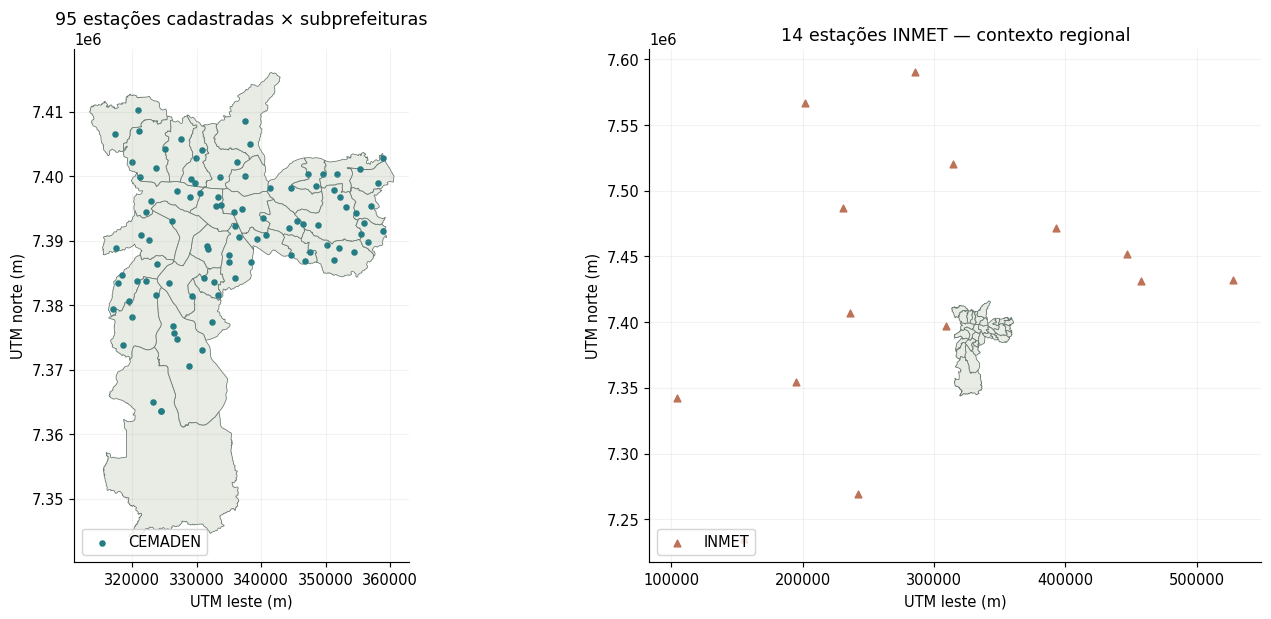

,codigo_subprefeitura,nome_subprefeitura,n_estacoes_cemaden_mapeadas
12,13,IPIRANGA,6
26,27,ITAQUERA,6
16,17,CAMPO LIMPO,5
18,19,CAPELA DO SOCORRO,5
17,18,M BOI MIRIM,5
1,02,PIRITUBA-JARAGUA,4
7,08,LAPA,4
3,04,CASA VERDE-LIMAO-CACHOEIRINHA,4
8,09,SE,4
29,30,SAO MATEUS,4


In [5]:
regioes_geo = limites[['codigo_subprefeitura','nome_subprefeitura','geometry']].copy()
pt_cem = gpd.GeoDataFrame(cemaden_estacoes,
    geometry=gpd.points_from_xy(cemaden_estacoes.lon,cemaden_estacoes.lat),crs='EPSG:4326').to_crs(limites.crs)
pt_inmet = gpd.GeoDataFrame(inmet_estacoes,
    geometry=gpd.points_from_xy(inmet_estacoes.lon,inmet_estacoes.lat),crs='EPSG:4326').to_crs(limites.crs)
atribuicoes = gpd.sjoin(pt_cem[['cod_estacao','geometry']],
                       regioes_geo[['codigo_subprefeitura','geometry']],how='left',predicate='within')
estacoes_regiao = atribuicoes.groupby('codigo_subprefeitura',dropna=True).cod_estacao.nunique()
regioes_geo['n_estacoes_cemaden_mapeadas'] = regioes_geo.codigo_subprefeitura.map(estacoes_regiao).fillna(0).astype(int)
print('Estações dentro dos polígonos:',int(atribuicoes.codigo_subprefeitura.notna().sum()),
      '| fora ou sobre fronteira:',int(atribuicoes.codigo_subprefeitura.isna().sum()))
fig,axes = plt.subplots(1,2,figsize=(14,6))
regioes_geo.plot(ax=axes[0],facecolor='#e8ece4',edgecolor='#6b7b73',linewidth=.55)
pt_cem.plot(ax=axes[0],color='#257c84',markersize=12,label='CEMADEN')
axes[0].set(title='95 estações cadastradas × subprefeituras',xlabel='UTM leste (m)',ylabel='UTM norte (m)')
axes[0].legend(loc='lower left')
regioes_geo.plot(ax=axes[1],facecolor='#e8ece4',edgecolor='#6b7b73',linewidth=.55)
pt_inmet.plot(ax=axes[1],color='#bd7257',marker='^',markersize=21,label='INMET')
axes[1].set(title='14 estações INMET — contexto regional',xlabel='UTM leste (m)',ylabel='UTM norte (m)')
axes[1].legend(loc='lower left')
figura('01_estacoes_e_subprefeituras')
display(regioes_geo[['codigo_subprefeitura','nome_subprefeitura','n_estacoes_cemaden_mapeadas']]
        .sort_values('n_estacoes_cemaden_mapeadas',ascending=False).head(12))

### 1.3 · Comparação das fontes de chuva e sazonalidade

A correlação entre medidas diárias ajuda a detectar discordâncias entre fontes, mas não comprova qual delas representa melhor cada subprefeitura. A reanálise Open-Meteo e o INMET não devem ser apresentados como observações pluviométricas locais de cada uma das 32 regiões.

,CEMADEN_IDW,INMET_IDW,OpenMeteo_historico
CEMADEN_IDW,1.000,0.786,0.766
INMET_IDW,0.786,1.000,0.812
OpenMeteo_historico,0.766,0.812,1.000


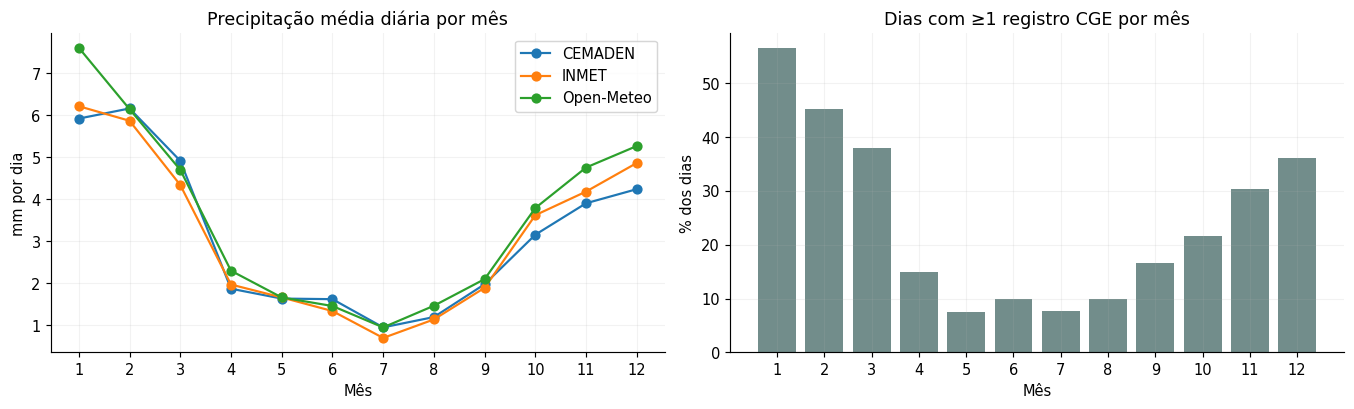

In [6]:
comparacao = (municipio[['date','has_flooding','cemaden_precip_idw_mm']]
    .merge(inmet_diario[['date','sp_precip_mm']],on='date',validate='one_to_one')
    .merge(open_meteo[['date','precipitation_sum']],on='date',validate='one_to_one'))
comparacao = comparacao.rename(columns={'cemaden_precip_idw_mm':'CEMADEN_IDW',
    'sp_precip_mm':'INMET_IDW','precipitation_sum':'OpenMeteo_historico'})
display(comparacao[['CEMADEN_IDW','INMET_IDW','OpenMeteo_historico']].corr(method='spearman').round(3))
comparacao['mes'] = comparacao.date.dt.month
sazonal = comparacao.groupby('mes').agg(chuva_cemaden=('CEMADEN_IDW','mean'),
        chuva_inmet=('INMET_IDW','mean'), chuva_openmeteo=('OpenMeteo_historico','mean'),
        pct_dias_cge=('has_flooding','mean')).reset_index()
fig,axes=plt.subplots(1,2,figsize=(13,4))
for var,legenda in [('chuva_cemaden','CEMADEN'),('chuva_inmet','INMET'),('chuva_openmeteo','Open-Meteo')]:
    axes[0].plot(sazonal.mes,sazonal[var],marker='o',label=legenda)
axes[0].set(title='Precipitação média diária por mês',xlabel='Mês',ylabel='mm por dia',xticks=range(1,13))
axes[0].legend()
axes[1].bar(sazonal.mes,100*sazonal.pct_dias_cge,color='#728d8b')
axes[1].set(title='Dias com ≥1 registro CGE por mês',xlabel='Mês',ylabel='% dos dias',xticks=range(1,13))
figura('02_sazonalidade_comparacao_fontes')

# 2 · Variáveis e suas associações por subprefeitura

Uma subprefeitura pode apresentar mais registros porque possui maior extensão, população, densidade viária, mais pontos monitorados ou diferentes condições de drenagem. Os dados enviados não medem todos esses fatores. **Associação ecológica não é impacto causal.**

A variável-alvo por região é `tem_registro_cge`; observamos 32 séries diárias do mesmo período e as enriquecemos com um **retrato** territorial de vegetação, drenagem e área. O mapa e as correlações a seguir são descrições retrospectivas, sem inferir que a vegetação de 2017 ou a drenagem cadastrada em 2026 eram iguais em 2015.

In [7]:
perfil = (painel_cge.groupby('codigo_subprefeitura',as_index=False)
   .agg(dias_calendario=('date','size'),dias_com_registro=('tem_registro_cge','sum'),
        registros=('n_registros_cge','sum'))
   .merge(urbano[['codigo_subprefeitura','nome_subprefeitura','area_km2',
                  'pct_area_mapeada_vegetacao','densidade_rede_km_por_km2',
                  'rede_mapeada_km']],on='codigo_subprefeitura',validate='one_to_one')
   .merge(regioes_geo[['codigo_subprefeitura','n_estacoes_cemaden_mapeadas']],
          on='codigo_subprefeitura',validate='one_to_one'))
perfil['pct_dias_registro'] = 100*perfil.dias_com_registro/perfil.dias_calendario
perfil['registros_por_100_km2'] = 100*perfil.registros/perfil.area_km2
assert len(perfil)==32
print('Total de dias-região com registro:',int(perfil.dias_com_registro.sum()))
display(perfil.sort_values('dias_com_registro',ascending=False)[
    ['nome_subprefeitura','dias_com_registro','registros','pct_dias_registro',
     'pct_area_mapeada_vegetacao','densidade_rede_km_por_km2',
     'n_estacoes_cemaden_mapeadas']].head(15).round(2))
perfil.to_csv(SAIDA/'perfil_subprefeituras.csv',index=False,encoding='utf-8-sig')

Total de dias-região com registro: 4520


,nome_subprefeitura,dias_com_registro,registros,pct_dias_registro,pct_area_mapeada_vegetacao,densidade_rede_km_por_km2,n_estacoes_cemaden_mapeadas
8,SE,519,1524,12.45,16.48,2.39,4
10,PINHEIROS,345,778,8.28,28.36,1.97,1
13,SANTO AMARO,330,773,7.92,29.35,2.13,2
7,LAPA,325,900,7.80,20.84,2.36,4
24,MOOCA,324,733,7.77,12.07,1.38,2
9,BUTANTA,254,476,6.09,38.05,2.78,3
26,ITAQUERA,241,473,5.78,39.40,2.79,6
4,SANTANA-TUCURUVI,236,423,5.66,36.28,2.99,2
11,VILA MARIANA,214,499,5.13,22.69,2.44,2
3,CASA VERDE-LIMAO-CACHOEIRINHA,187,348,4.49,30.85,3.27,4


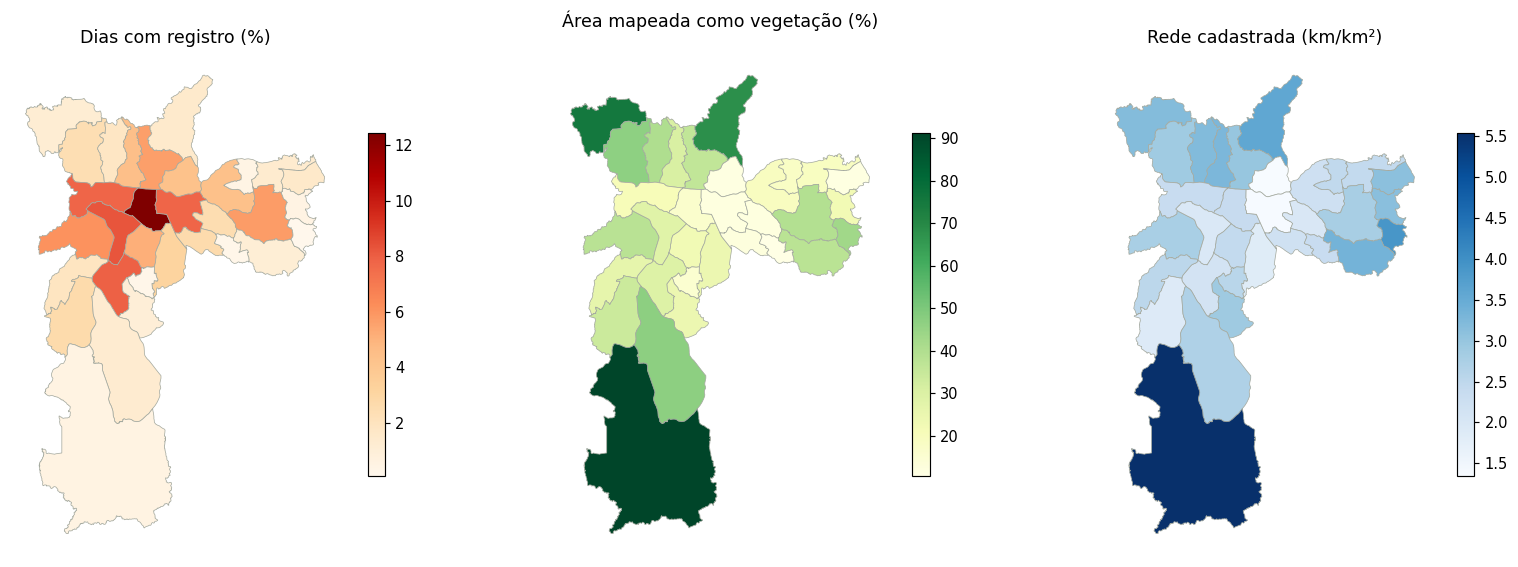

In [8]:
mapa = limites[['codigo_subprefeitura','nome_subprefeitura','geometry']].merge(
    perfil[['codigo_subprefeitura','pct_dias_registro','pct_area_mapeada_vegetacao',
            'densidade_rede_km_por_km2']],on='codigo_subprefeitura',validate='one_to_one')
fig,axes=plt.subplots(1,3,figsize=(16,5.5))
for ax,var,titulo,cmap in zip(axes,['pct_dias_registro','pct_area_mapeada_vegetacao',
                                      'densidade_rede_km_por_km2'],
                                ['Dias com registro (%)','Área mapeada como vegetação (%)',
                                 'Rede cadastrada (km/km²)'],['OrRd','YlGn','Blues']):
    mapa.plot(column=var,ax=ax,cmap=cmap,edgecolor='#a5aaa0',linewidth=.5,
              legend=True,legend_kwds={'shrink':.68})
    ax.set_title(titulo);ax.axis('off')
figura('03_mapas_subprefeituras')

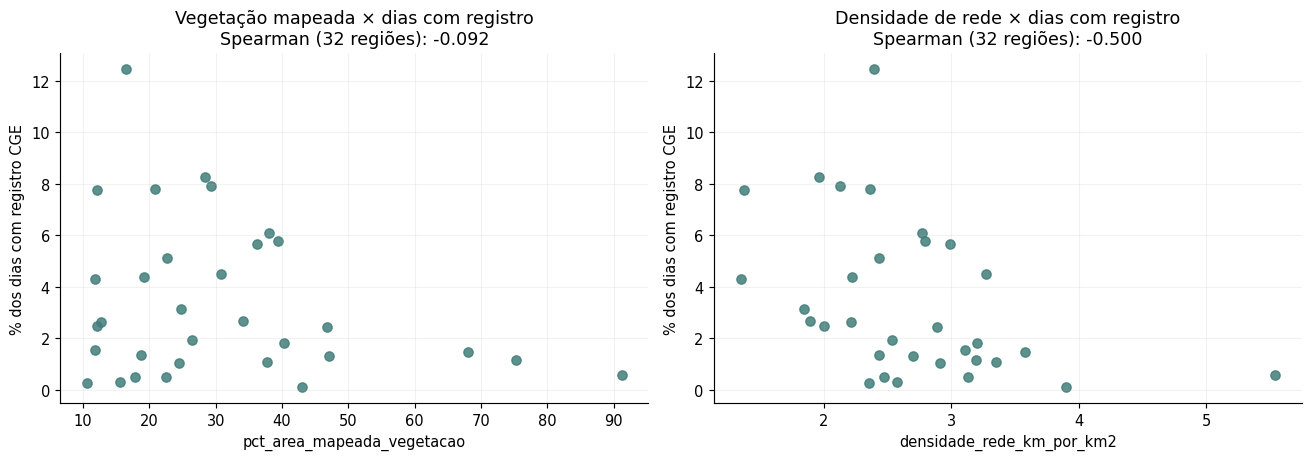

,variavel,spearman,n_subprefeituras
0,pct_area_mapeada_vegetacao,-0.092,32
1,densidade_rede_km_por_km2,-0.500,32
2,area_km2,0.283,32


In [9]:
colunas_urbanas=['pct_area_mapeada_vegetacao','densidade_rede_km_por_km2','area_km2']
correlacoes = []
fig,axes=plt.subplots(1,2,figsize=(12.6,4.5))
for ax,col,titulo in zip(axes,colunas_urbanas[:2],
                         ['Vegetação mapeada × dias com registro','Densidade de rede × dias com registro']):
    r,_ = spearmanr(perfil[col],perfil.pct_dias_registro)
    ax.scatter(perfil[col],perfil.pct_dias_registro,alpha=.85,color='#427e7a',s=40)
    ax.set(title=f'{titulo}\nSpearman (32 regiões): {r:+.3f}',xlabel=col,
           ylabel='% dos dias com registro CGE')
    correlacoes.append({'variavel':col,'spearman':r,'n_subprefeituras':len(perfil)})
for col in colunas_urbanas[2:]:
    r,_=spearmanr(perfil[col],perfil.pct_dias_registro)
    correlacoes.append({'variavel':col,'spearman':r,'n_subprefeituras':len(perfil)})
figura('04_associacao_ecologica_urbana')
correlacoes_urbanas=pd.DataFrame(correlacoes)
display(correlacoes_urbanas.round(3))
correlacoes_urbanas.to_csv(SAIDA/'correlacoes_urbanas_descritivas.csv',index=False)

### 2.1 · Chuva antecedente e eventos por subprefeitura

Reproduzimos a investigação de D+0 a D+3 do caderno EDA original. Para o recorte regional, a chuva é a **mesma série municipal** em cada subprefeitura e não deve ser apresentada como chuva local. A estatística avalia associação defasada, não acerto de previsão nem efeito causal.

In [10]:
resultado_lags=[]
for horizonte in [0,1,2,3]:
    y=municipio.has_flooding.shift(-horizonte)
    valid=y.notna() & municipio.cemaden_precip_idw_mm.notna()
    r,_=spearmanr(municipio.loc[valid,'cemaden_precip_idw_mm'],y[valid])
    resultado_lags.append({'horizonte_dias':horizonte,'spearman_chuva_municipal_vs_registro':r,
                           'dias':int(valid.sum())})
df_lags=pd.DataFrame(resultado_lags)
display(df_lags.round(4))
painel_chuva = painel_cge.sort_values(['codigo_subprefeitura','date']).merge(
    municipio[['date','cemaden_precip_idw_mm']],on='date',validate='many_to_one')
painel_chuva['registro_amanha']=(painel_chuva.groupby('codigo_subprefeitura')
                                              .tem_registro_cge.shift(-1))
linhas_cor=[]
for codigo,g in painel_chuva.groupby('codigo_subprefeitura'):
    g=g.dropna(subset=['registro_amanha','cemaden_precip_idw_mm'])
    positivos=int(g.registro_amanha.sum())
    r=float(spearmanr(g.cemaden_precip_idw_mm,g.registro_amanha).statistic) if positivos>=10 else np.nan
    linhas_cor.append({'codigo_subprefeitura':codigo,'positivos_dia_seguinte':positivos,
                       'spearman_chuva_municipal_t_vs_registro_local_t1':r})
correlacao_regional = pd.DataFrame(linhas_cor).merge(urbano[['codigo_subprefeitura','nome_subprefeitura']],
                                                      on='codigo_subprefeitura')
print('Associações regionais não calculadas com menos de dez positivos:',
      int(correlacao_regional.spearman_chuva_municipal_t_vs_registro_local_t1.isna().sum()))
display(correlacao_regional.sort_values('positivos_dia_seguinte',ascending=False).head(12).round(4))
df_lags.to_csv(SAIDA/'associacao_temporal_municipal.csv',index=False)
correlacao_regional.to_csv(SAIDA/'associacao_chuva_regional.csv',index=False)

,horizonte_dias,spearman_chuva_municipal_vs_registro,dias
0,0,0.6239,4169
1,1,0.3753,4168
2,2,0.2643,4167
3,3,0.2274,4166


Associações regionais não calculadas com menos de dez positivos: 1


,codigo_subprefeitura,positivos_dia_seguinte,spearman_chuva_municipal_t_vs_registro_local_t1,nome_subprefeitura
8,09,519,0.2783,SE
10,11,345,0.2020,PINHEIROS
13,14,330,0.2261,SANTO AMARO
7,08,325,0.2184,LAPA
24,25,324,0.2122,MOOCA
9,10,254,0.1960,BUTANTA
26,27,241,0.1708,ITAQUERA
4,05,236,0.2047,SANTANA-TUCURUVI
11,12,214,0.1757,VILA MARIANA
3,04,187,0.1486,CASA VERDE-LIMAO-CACHOEIRINHA


### 2.2 · Limitações que afetam a interpretação de 'impacto'

- **Características urbanas fixas:** não variam ao longo dos dias dentro de uma mesma subprefeitura. Uma correlação com taxa de registros pode refletir diferenças estruturais e de exposição não medidas; não estima o efeito de plantar árvores ou construir galerias.
- **Drenagem:** maior rede cadastrada pode coincidir com áreas historicamente mais sujeitas a alagamento, devido à priorização de intervenções. O comprimento não mede vazão, manutenção ou suficiência hidráulica.
- **Vegetação:** área mapeada é cobertura classificada no voo de 2017, e não percentual impermeável. As categorias espaciais podem se sobrepor.
- **Chuva:** os anexos contêm a série diária municipal e metadados das 95 estações; faltam os CSVs por estação-dia para interpolar precipitação por região.
- **Coleta:** não podemos usar um dia sem registro como confirmação de que nenhum alagamento ocorreu.

A avaliação mais útil com estes arquivos é uma **ablação preditiva retrospectiva**: manter modelo, divisão e amostra idênticos e comparar adicionar/retirar covariáveis urbanas. Mesmo um ganho nessa ablação não comprova causalidade.

# 3 · Modelagem de Machine Learning (dia seguinte)

Mantemos dois níveis de referência do caderno original: (A) previsão **municipal** de ao menos um registro em D+1; (B) previsão de **registro por subprefeitura** em D+1. Para o segundo, o modelo é treinado com as 32 regiões juntas; assim, uma região com poucos eventos não precisa sustentar um classificador isolado. A avaliação sempre agrupa as 32 observações de um mesmo dia na mesma partição temporal.

Uma previsão D+1 aqui assume que todos os dados do dia `t` já foram encerrados e estão disponíveis antes de prever `t+1`. A latência operacional dos pluviômetros, do INMET e do CGE ainda precisa ser verificada. Open-Meteo histórico e drenagem 2026 não são tratados como preditores operacionais históricos.

In [11]:
# Corte padronizado pelos alvos, com uma data de embargo nas fronteiras.
def separar_tempo(dados, alvo, informacao='date', alvo_data='data_alvo'):
    treino = dados.loc[dados[alvo_data] < '2022-01-01'].copy()
    valid = dados.loc[dados[alvo_data].between('2022-01-01','2023-12-31')].copy()
    teste = dados.loc[dados[alvo_data] >= '2024-01-01'].copy()
    treino = treino.loc[treino[alvo_data] < valid[informacao].min()].copy()
    valid = valid.loc[valid[alvo_data] < teste[informacao].min()].copy()
    assert treino[alvo_data].max() < valid[informacao].min()
    assert valid[alvo_data].max() < teste[informacao].min()
    for d in [treino,valid,teste]:
        assert d[alvo].notna().all() and d[alvo].nunique()==2
    return treino,valid,teste

def metricas(y,p,limiar=.5):
    y=np.asarray(y).astype(int); p=np.asarray(p,dtype=float)
    previsto=(p>=limiar).astype(int)
    assert np.isfinite(p).all() and ((p>=0)&(p<=1)).all()
    return {'AP':average_precision_score(y,p) if len(np.unique(y))==2 else np.nan,
      'ROC_AUC':roc_auc_score(y,p) if len(np.unique(y))==2 else np.nan,
      'Brier':brier_score_loss(y,p),
      'precisao':precision_score(y,previsto,zero_division=0),
      'recall':recall_score(y,previsto,zero_division=0),
      'F1':f1_score(y,previsto,zero_division=0),
      'acuracia':accuracy_score(y,previsto),
      'fracao_alertas':previsto.mean()}

def limiar_validado(y,p):
    linhas=[{'limiar':float(x),**metricas(y,p,x)} for x in np.arange(.01,.501,.01)]
    return float(pd.DataFrame(linhas).sort_values(['F1','recall','limiar'],ascending=False).iloc[0]['limiar'])

## 3A · Baseline municipal original reproduzido

As variáveis do baseline são precipitação IDW municipal no dia `t`, defasagens e acumulados até `t`, além do mês de `t+1`. Não entram `n_events`, alagamento de amanhã, precipitação do futuro, máximos residuais suspeitos ou erro de previsão da Previous Runs. O controle de calendário verifica se o aprendizado meteorológico acrescenta discriminação sazonal.

In [12]:
municipal = municipio[['date','has_flooding','cemaden_precip_idw_mm']].copy()
municipal['data_alvo'] = municipal.date+pd.Timedelta(days=1)
municipal['alvo_amanha'] = municipal.has_flooding.shift(-1)
municipal['chuva_t'] = municipal.cemaden_precip_idw_mm
for n in [1,2,3]:municipal[f'chuva_lag{n}'] = municipal.chuva_t.shift(n)
for n in [3,7,14]:municipal[f'chuva_acc{n}'] = municipal.chuva_t.rolling(n,min_periods=n).sum()
municipal['mes_sin']=np.sin(2*np.pi*(municipal.data_alvo.dt.month-1)/12)
municipal['mes_cos']=np.cos(2*np.pi*(municipal.data_alvo.dt.month-1)/12)
municipal=municipal.dropna(subset=['alvo_amanha']).copy()
municipal['alvo_amanha']=municipal.alvo_amanha.astype(int)
CAL=['mes_sin','mes_cos']
METEOM=['chuva_t','chuva_lag1','chuva_lag2','chuva_lag3',
        'chuva_acc3','chuva_acc7','chuva_acc14',*CAL]
tr_m,va_m,te_m=separar_tempo(municipal,'alvo_amanha')
print('Municipal — treino / validação / teste:',len(tr_m),len(va_m),len(te_m))
print('Prevalências:',*[f'{p.alvo_amanha.mean():.1%}' for p in [tr_m,va_m,te_m]])
def logistica():
    return Pipeline([('imputacao',SimpleImputer(strategy='median')),
       ('padronizacao',StandardScaler()),
       ('classificador',LogisticRegression(max_iter=1500,random_state=SEMENTE))])
modelos_municipais={
  'Referência constante':(DummyClassifier(strategy='prior'),METEOM),
  'Apenas calendário':(logistica(),CAL),
  'Logística chuva':(logistica(),METEOM),
  'Random Forest chuva':(Pipeline([('imputacao',SimpleImputer(strategy='median')),
      ('classificador',RandomForestClassifier(n_estimators=200,max_depth=6,
               min_samples_leaf=20,n_jobs=-1,random_state=SEMENTE))]),METEOM)
}
linhas_m_val=[];linhas_m_teste=[];pred_m_teste={};modelos_m_treinados={};limiares_m={}
for nome,(est,cols) in modelos_municipais.items():
    ajustado=clone(est).fit(tr_m[cols],tr_m.alvo_amanha)
    pval=ajustado.predict_proba(va_m[cols])[:,1]
    lim=.5 if nome=='Referência constante' else limiar_validado(va_m.alvo_amanha,pval)
    ptest=ajustado.predict_proba(te_m[cols])[:,1]
    modelos_m_treinados[nome]=ajustado;pred_m_teste[nome]=ptest;limiares_m[nome]=lim
    linhas_m_val.append({'modelo':nome,'limiar':lim,**metricas(va_m.alvo_amanha,pval,lim)})
    linhas_m_teste.append({'modelo':nome,'limiar':lim,**metricas(te_m.alvo_amanha,ptest,lim)})
met_m_val=pd.DataFrame(linhas_m_val).set_index('modelo')
met_m_teste=pd.DataFrame(linhas_m_teste).set_index('modelo')
print('VALIDAÇÃO municipal:');display(met_m_val.round(3))
print('TESTE municipal reservado (sem usar para seleção):');display(met_m_teste.round(3))
selecionado_municipal = met_m_val.loc[['Logística chuva','Random Forest chuva'],'AP'].idxmax()
print('Candidato municipal selecionado na validação:',selecionado_municipal,
      '| AP teste reservado:',f'{met_m_teste.at[selecionado_municipal,"AP"]:.3f}')
met_m_val.to_csv(SAIDA/'metricas_municipal_validacao.csv',encoding='utf-8-sig')
met_m_teste.to_csv(SAIDA/'metricas_municipal_teste.csv',encoding='utf-8-sig')

Municipal — treino / validação / teste: 2555 729 882
Prevalências: 26.3% 24.4% 20.2%
VALIDAÇÃO municipal:


,limiar,AP,ROC_AUC,Brier,precisao,recall,F1,acuracia,fracao_alertas
modelo,,,,,,,,,
Referência constante,0.50,0.244,0.500,0.185,0.000,0.000,0.000,0.756,0.000
Apenas calendário,0.24,0.482,0.775,0.155,0.413,0.843,0.555,0.669,0.498
Logística chuva,0.38,0.594,0.815,0.142,0.558,0.596,0.576,0.786,0.261
Random Forest chuva,0.43,0.621,0.809,0.142,0.605,0.567,0.586,0.804,0.229


TESTE municipal reservado (sem usar para seleção):


,limiar,AP,ROC_AUC,Brier,precisao,recall,F1,acuracia,fracao_alertas
modelo,,,,,,,,,
Referência constante,0.50,0.202,0.500,0.165,0.000,0.000,0.000,0.798,0.000
Apenas calendário,0.24,0.431,0.777,0.142,0.330,0.843,0.474,0.622,0.516
Logística chuva,0.38,0.480,0.804,0.135,0.482,0.596,0.533,0.789,0.249
Random Forest chuva,0.43,0.437,0.799,0.137,0.471,0.506,0.488,0.786,0.217


Candidato municipal selecionado na validação: Random Forest chuva | AP teste reservado: 0.437


### 3A.1 · Estabilidade do baseline municipal em janelas históricas

Mantemos as janelas de 2019, 2020 e 2021 do caderno de modelagem original: em cada ano, o classificador é novamente ajustado **somente com os alvos anteriores** (e uma data de embargo), sem acesso à validação de 2022–2023 ou ao teste de 2024+. O diagnóstico mostra a AP junto da prevalência anual; não é usado para escolher hiperparâmetros depois de olhar o teste.

In [13]:
cv_m=[]
for ano in [2019,2020,2021]:
    g=tr_m.loc[tr_m.data_alvo.dt.year==ano]
    anterior=tr_m.loc[tr_m.data_alvo<g.date.min()]
    assert anterior.data_alvo.max()<g.date.min()
    for nome,(estimador,cols) in modelos_municipais.items():
        mod=clone(estimador).fit(anterior[cols],anterior.alvo_amanha)
        probs=mod.predict_proba(g[cols])[:,1]
        cv_m.append({'ano_validacao':ano,'modelo':nome,'dias':len(g),
                     'prevalencia':g.alvo_amanha.mean(),
                     'AP':average_precision_score(g.alvo_amanha,probs)})
cv_municipal=pd.DataFrame(cv_m)
print('AP por janela histórica (treinamento expansivo):')
display(cv_municipal.pivot(index='ano_validacao',columns='modelo',values='AP').round(3))
cv_municipal.to_csv(SAIDA/'validacao_historica_municipal.csv',index=False,encoding='utf-8-sig')
por_ano_m=[]
for ano,g in te_m.assign(score=pred_m_teste[selecionado_municipal]).groupby(te_m.data_alvo.dt.year):
    por_ano_m.append({'ano':ano,'dias':len(g),'prevalencia':g.alvo_amanha.mean(),
      **metricas(g.alvo_amanha,g.score,limiares_m[selecionado_municipal])})
por_ano_m=pd.DataFrame(por_ano_m)
print('Variação anual do teste municipal; 2026 é parcial:')
display(por_ano_m.round(3))
por_ano_m.to_csv(SAIDA/'metricas_municipal_teste_por_ano.csv',index=False,encoding='utf-8-sig')

AP por janela histórica (treinamento expansivo):


modelo,Apenas calendário,Logística chuva,Random Forest chuva,Referência constante
ano_validacao,,,,
2019,0.522,0.520,0.546,0.279
2020,0.417,0.518,0.512,0.235
2021,0.443,0.479,0.515,0.228


Variação anual do teste municipal; 2026 é parcial:


,ano,dias,prevalencia,AP,ROC_AUC,Brier,precisao,recall,F1,acuracia,fracao_alertas
0,2024,366,0.186,0.458,0.840,0.121,0.514,0.529,0.522,0.820,0.191
1,2025,365,0.216,0.487,0.784,0.142,0.522,0.456,0.486,0.792,0.189
2,2026,151,0.205,0.348,0.750,0.160,0.346,0.581,0.434,0.689,0.344


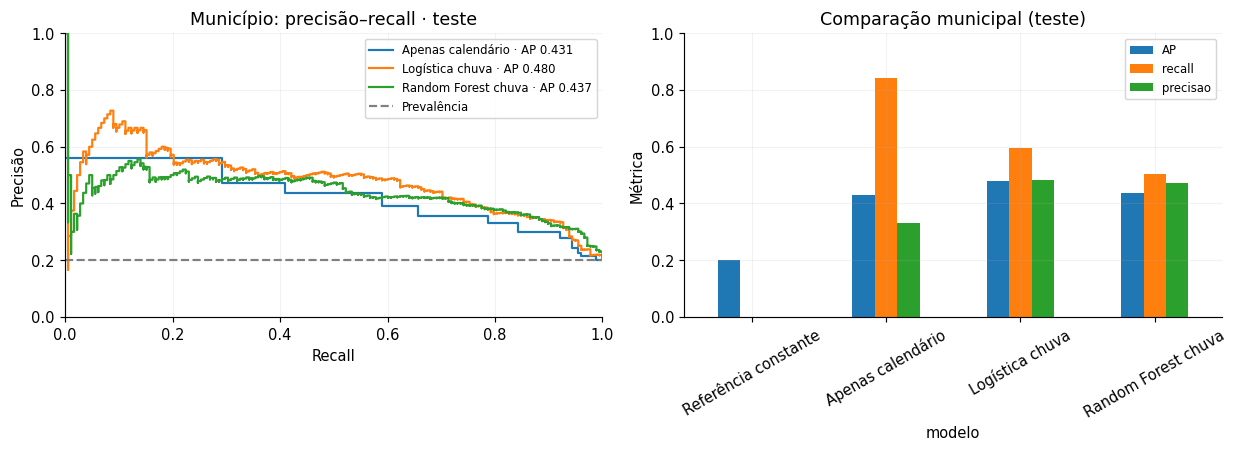

In [14]:
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
for nome,p in pred_m_teste.items():
    if nome=='Referência constante':continue
    pre,rec,_=precision_recall_curve(te_m.alvo_amanha,p)
    axes[0].step(rec,pre,where='post',label=f'{nome} · AP {met_m_teste.at[nome,"AP"]:.3f}')
axes[0].axhline(te_m.alvo_amanha.mean(),ls='--',color='gray',label='Prevalência')
axes[0].set(xlim=(0,1),ylim=(0,1),xlabel='Recall',ylabel='Precisão',title='Município: precisão–recall · teste')
axes[0].legend(fontsize=8)
# Gráfico descritivo de métricas; não reajustar os modelos após olhar o teste.
met_m_teste[['AP','recall','precisao']].plot(kind='bar',ax=axes[1],rot=30)
axes[1].set(title='Comparação municipal (teste)',ylim=(0,1),ylabel='Métrica')
axes[1].legend(fontsize=8)
figura('05_baseline_municipal')

## 3B · Dataset região-dia para o modelo territorial

Cada linha contém o mesmo dia meteorológico municipal e os atributos da região. Fazemos `shift(-1)` **dentro de cada subprefeitura**, não na tabela inteira. A última data de cada região fica sem alvo e é excluída. `n_registros_cge` e `tem_registro_cge` do dia-alvo **nunca** entram nas variáveis. O código regional é codificado por dummies conhecidas de antemão.

**Atenção:** `pct_area_mapeada_vegetacao`, `densidade_rede_km_por_km2` e `area_km2` são retratos estáticos; o modelo com elas é uma análise *retrospectiva com informação ex post*. Para uma avaliação prospectiva, será necessário reconstruir a versão histórica das camadas e incluir meteorologia regional efetivamente disponível no momento da previsão.

In [15]:
CLIMA=['cemaden_precip_idw_mm','cemaden_precip_lag1d','cemaden_precip_lag2d',
       'cemaden_precip_lag3d','cemaden_precip_acc3d','cemaden_precip_acc7d',
       'cemaden_precip_acc14d','sp_precip_mm',*CAL]
URB=['pct_area_mapeada_vegetacao','densidade_rede_km_por_km2','area_km2']
clima_dia=(municipio[['date','cemaden_precip_idw_mm','cemaden_precip_lag1d',
    'cemaden_precip_lag2d','cemaden_precip_lag3d','cemaden_precip_acc3d',
    'cemaden_precip_acc7d','cemaden_precip_acc14d']]
    .merge(inmet_diario[['date','sp_precip_mm']],on='date',validate='one_to_one'))
painel=(painel_cge[['date','codigo_subprefeitura','n_registros_cge',
                    'tem_registro_cge','dia_presente_base_cge']]
    .merge(clima_dia,on='date',validate='many_to_one')
    .merge(urbano[['codigo_subprefeitura','nome_subprefeitura',*URB]],
           on='codigo_subprefeitura',validate='many_to_one')
    .sort_values(['codigo_subprefeitura','date']).reset_index(drop=True))
painel['data_alvo']=painel.date+pd.Timedelta(days=1)
painel['alvo_regiao_amanha']=painel.groupby('codigo_subprefeitura').tem_registro_cge.shift(-1)
painel['mes_sin']=np.sin(2*np.pi*(painel.data_alvo.dt.month-1)/12)
painel['mes_cos']=np.cos(2*np.pi*(painel.data_alvo.dt.month-1)/12)
painel=painel.dropna(subset=['alvo_regiao_amanha']).copy()
painel['alvo_regiao_amanha']=painel.alvo_regiao_amanha.astype(int)
dummies=pd.get_dummies(painel.codigo_subprefeitura,prefix='regiao',dtype=np.int8)
painel=painel.join(dummies)
REG=list(dummies.columns)
assert len(REG)==32
assert (painel.data_alvo-painel.date).eq(pd.Timedelta(days=1)).all()
assert painel.groupby('codigo_subprefeitura').size().eq(len(municipio)-1).all()
assert set(CLIMA+URB+REG).isdisjoint({'alvo_regiao_amanha','tem_registro_cge','n_registros_cge'})
tr,va,te=separar_tempo(painel,'alvo_regiao_amanha')
resumo_cortes=pd.DataFrame([{'conjunto':k,'inicio_alvo':z.data_alvo.min().date(),
    'fim_alvo':z.data_alvo.max().date(),'linhas_regiao_dia':len(z),
    'dias_unicos':z.data_alvo.nunique(),'positivos':int(z.alvo_regiao_amanha.sum()),
    'prevalencia':z.alvo_regiao_amanha.mean()}
    for k,z in [('Treino',tr),('Validação',va),('Teste',te)]])
display(resumo_cortes)
resumo_cortes.to_csv(SAIDA/'divisao_temporal_regional.csv',index=False,encoding='utf-8-sig')
# Exportamos a base inteira de estudo com a proveniência explícita. NÃO é histórico urbano real.
painel[['date','data_alvo','codigo_subprefeitura','nome_subprefeitura',
        'alvo_regiao_amanha',*CLIMA,*URB]].to_csv(SAIDA/'painel_modelagem_retrosp.csv',
                                                 index=False,encoding='utf-8-sig')

,conjunto,inicio_alvo,fim_alvo,linhas_regiao_dia,dias_unicos,positivos,prevalencia
0,Treino,2015-01-02,2021-12-30,81760,2555,2864,0.035029
1,Validação,2022-01-01,2023-12-30,23328,729,805,0.034508
2,Teste,2024-01-01,2026-05-31,28224,882,847,0.030010


## 3C · Ablação preditiva com amostra e algoritmo idênticos

Comparamos cinco referências/cenários usando o **mesmo classificador de árvores e os mesmos hiperparâmetros** nas quatro versões treinadas. Isso separa a contribuição descritiva dos grupos de variáveis de diferenças introduzidas por algoritmos diferentes:

1. **Frequência histórica regional** (referência; estimativa suavizada a partir do treino de cada região).
2. **Clima municipal:** chuva CEMADEN/INMET + calendário, igual para todas as regiões em cada dia.
3. **Clima + região:** adiciona identificação categórica da subprefeitura (histórico geográfico sem atributos urbanos medidos).
4. **Clima + urbano:** adiciona vegetação, drenagem e área, **sem** dummies territoriais.
5. **Clima + região + urbano:** combina dummies e atributos; a colinearidade entre ambos limita qualquer interpretação isolada da importância.

A comparação de 2 e 4 examina o valor de informação dos atributos urbanos; a comparação de 3 e 5 verifica seu incremento além da própria identidade regional. **Não** é experimento causal. Métricas finais do teste só são calculadas depois da escolha, baseada exclusivamente na AP de validação.

In [16]:
CENARIOS={
    'Clima municipal':CLIMA,
    'Clima + região':CLIMA+REG,
    'Clima + urbano':CLIMA+URB,
    'Clima + região + urbano':CLIMA+REG+URB,
}
# HistGradientBoosting trata ausências nos primeiros lags sem imputar a partir do teste.
def modelo_regional():
    return HistGradientBoostingClassifier(max_iter=115,max_leaf_nodes=15,
        learning_rate=.065,min_samples_leaf=80,l2_regularization=1,
        early_stopping=False,random_state=SEMENTE)
# Referência por região, suavizada para limitar extremos de regiões raras.
prior_geral=tr.alvo_regiao_amanha.mean()
taxas=tr.groupby('codigo_subprefeitura').alvo_regiao_amanha.agg(['sum','count'])
alpha=100
taxas['prior_suavizado']=(taxas['sum']+alpha*prior_geral)/(taxas['count']+alpha)
def previsao_referencia(df):
    return df.codigo_subprefeitura.map(taxas.prior_suavizado).fillna(prior_geral).to_numpy()

models={};val_probs={};test_probs={};lims={}
metricas_val=[]
p_prior=previsao_referencia(va)
val_probs['Histórico por região']=p_prior
lims['Histórico por região']=limiar_validado(va.alvo_regiao_amanha,p_prior)
metricas_val.append({'experimento':'Histórico por região','limiar':lims['Histórico por região'],
                     **metricas(va.alvo_regiao_amanha,p_prior,lims['Histórico por região'])})
for nome,colunas in CENARIOS.items():
    mdl=modelo_regional().fit(tr[colunas],tr.alvo_regiao_amanha)
    pv=mdl.predict_proba(va[colunas])[:,1]
    models[nome]=mdl;val_probs[nome]=pv
    lims[nome]=limiar_validado(va.alvo_regiao_amanha,pv)
    metricas_val.append({'experimento':nome,'limiar':lims[nome],
                         **metricas(va.alvo_regiao_amanha,pv,lims[nome])})
resultado_reg_val=pd.DataFrame(metricas_val).set_index('experimento')
selecionado=resultado_reg_val.loc[list(CENARIOS),'AP'].idxmax()
print('VALIDAÇÃO do painel regional (AP decide a escolha):')
display(resultado_reg_val.round(3))
print('Experimento selecionado apenas pela validação:',selecionado,
      '| limiar escolhido na validação:',round(lims[selecionado],3))
resultado_reg_val.to_csv(SAIDA/'metricas_regional_validacao.csv',encoding='utf-8-sig')

VALIDAÇÃO do painel regional (AP decide a escolha):


,limiar,AP,ROC_AUC,Brier,precisao,recall,F1,acuracia,fracao_alertas
experimento,,,,,,,,,
Histórico por região,0.07,0.078,0.726,0.033,0.086,0.391,0.142,0.836,0.156
Clima municipal,0.08,0.091,0.768,0.032,0.112,0.391,0.174,0.872,0.121
Clima + região,0.15,0.175,0.833,0.031,0.228,0.298,0.258,0.941,0.045
Clima + urbano,0.11,0.163,0.833,0.031,0.184,0.424,0.257,0.915,0.079
Clima + região + urbano,0.13,0.164,0.833,0.031,0.196,0.350,0.252,0.928,0.062


Experimento selecionado apenas pela validação: Clima + região | limiar escolhido na validação: 0.15


## 3D · Teste reservado e diagnóstico por subprefeitura

Apresentamos os cinco cenários para transparência, mas o escolhido na validação permanece congelado. **AP (Average Precision)** é mais informativa que acurácia quando poucos dias-região têm registros, mas deve ser lida junto à prevalência da amostra. O limiar para transformar probabilidade em alerta usa apenas a validação, não o teste.

Por região, AP/recall têm grande incerteza quando há poucos registros: a tabela sinaliza regiões com menos de cinco positivos no teste, em vez de transformar seus números em comparações confiáveis.

In [17]:
linhas=[]
for nome in ['Histórico por região',*CENARIOS]:
    p=previsao_referencia(te) if nome=='Histórico por região' else models[nome].predict_proba(te[CENARIOS[nome]])[:,1]
    test_probs[nome]=p
    linhas.append({'experimento':nome,'limiar':lims[nome],
                   **metricas(te.alvo_regiao_amanha,p,lims[nome])})
resultado_reg_teste=pd.DataFrame(linhas).set_index('experimento')
print('TESTE REGIONAL (2024–maio/2026, período de 2026 incompleto):')
display(resultado_reg_teste.round(3))
resultado_reg_teste.to_csv(SAIDA/'metricas_regional_teste.csv',encoding='utf-8-sig')
predicoes=te[['date','data_alvo','codigo_subprefeitura','nome_subprefeitura',
             'alvo_regiao_amanha']].copy()
predicoes['score']=test_probs[selecionado]
predicoes['alerta']=(predicoes.score>=lims[selecionado]).astype(int)
predicoes['limiar']=lims[selecionado]
predicoes['experimento']=selecionado
predicoes.to_csv(SAIDA/'previsoes_teste_por_subprefeitura.csv',index=False,encoding='utf-8-sig')
linhas_region=[]
for codigo,g in predicoes.groupby('codigo_subprefeitura'):
    n=int(g.alvo_regiao_amanha.sum())
    valido=n>=5 and n<len(g)
    met=metricas(g.alvo_regiao_amanha,g.score,lims[selecionado])
    linhas_region.append({'codigo_subprefeitura':codigo,
      'nome_subprefeitura':g.nome_subprefeitura.iloc[0],
      'dias':len(g),'positivos':n,'prevalencia':g.alvo_regiao_amanha.mean(),
      'AP':met['AP'] if valido else np.nan,'recall':met['recall'] if valido else np.nan,
      'precisao':met['precisao'] if valido else np.nan,
      'Brier':met['Brier'],'avaliacao_confiavel_min_5_positivos':valido})
por_regiao=pd.DataFrame(linhas_region).sort_values('positivos',ascending=False)
print('Regiões com menos de 5 positivos no teste:',int((~por_regiao.avaliacao_confiavel_min_5_positivos).sum()))
display(por_regiao.head(12).round(3))
por_regiao.to_csv(SAIDA/'metricas_teste_por_subprefeitura.csv',index=False,encoding='utf-8-sig')

TESTE REGIONAL (2024–maio/2026, período de 2026 incompleto):


,limiar,AP,ROC_AUC,Brier,precisao,recall,F1,acuracia,fracao_alertas
experimento,,,,,,,,,
Histórico por região,0.07,0.060,0.705,0.029,0.066,0.342,0.110,0.834,0.156
Clima municipal,0.08,0.068,0.749,0.029,0.071,0.301,0.114,0.860,0.128
Clima + região,0.15,0.111,0.820,0.028,0.138,0.227,0.172,0.934,0.049
Clima + urbano,0.11,0.108,0.817,0.028,0.124,0.354,0.184,0.906,0.085
Clima + região + urbano,0.13,0.110,0.819,0.028,0.136,0.308,0.188,0.920,0.068


Regiões com menos de 5 positivos no teste: 6


,codigo_subprefeitura,nome_subprefeitura,dias,positivos,prevalencia,AP,recall,precisao,Brier,avaliacao_confiavel_min_5_positivos
8,09,SE,882,81,0.092,0.212,0.642,0.184,0.080,True
7,08,LAPA,882,61,0.069,0.139,0.393,0.146,0.063,True
26,27,ITAQUERA,882,56,0.063,0.126,0.107,0.128,0.058,True
9,10,BUTANTA,882,54,0.061,0.153,0.259,0.171,0.055,True
10,11,PINHEIROS,882,54,0.061,0.153,0.444,0.140,0.056,True
24,25,MOOCA,882,49,0.056,0.122,0.490,0.128,0.054,True
4,05,SANTANA-TUCURUVI,882,47,0.053,0.118,0.255,0.145,0.049,True
13,14,SANTO AMARO,882,45,0.051,0.116,0.422,0.112,0.050,True
20,21,PENHA,882,41,0.046,0.137,0.024,0.100,0.042,True
11,12,VILA MARIANA,882,39,0.044,0.152,0.231,0.138,0.040,True


### 3D.1 · Estabilidade anual do experimento regional

O teste abrange três períodos climáticos desiguais, pois 2026 vai apenas até maio. As métricas anuais abaixo usam o **mesmo modelo e limiar** escolhidos na validação; não ajustam os resultados a posteriori.

In [18]:
por_ano_r=[]
for ano,g in predicoes.groupby(predicoes.data_alvo.dt.year):
    por_ano_r.append({'ano':ano,'dias_regiao':len(g),'regioes':g.codigo_subprefeitura.nunique(),
        'positivos':int(g.alvo_regiao_amanha.sum()),
        'prevalencia':g.alvo_regiao_amanha.mean(),
        **metricas(g.alvo_regiao_amanha,g.score,lims[selecionado])})
por_ano_r=pd.DataFrame(por_ano_r)
display(por_ano_r.round(3))
por_ano_r.to_csv(SAIDA/'metricas_regionais_teste_por_ano.csv',index=False,encoding='utf-8-sig')

,ano,dias_regiao,regioes,positivos,prevalencia,AP,ROC_AUC,Brier,precisao,recall,F1,acuracia,fracao_alertas
0,2024,11712,32,348,0.030,0.120,0.826,0.028,0.153,0.210,0.177,0.942,0.041
1,2025,11680,32,339,0.029,0.113,0.824,0.027,0.145,0.215,0.173,0.940,0.043
2,2026,4832,32,160,0.033,0.107,0.804,0.032,0.112,0.288,0.161,0.901,0.085


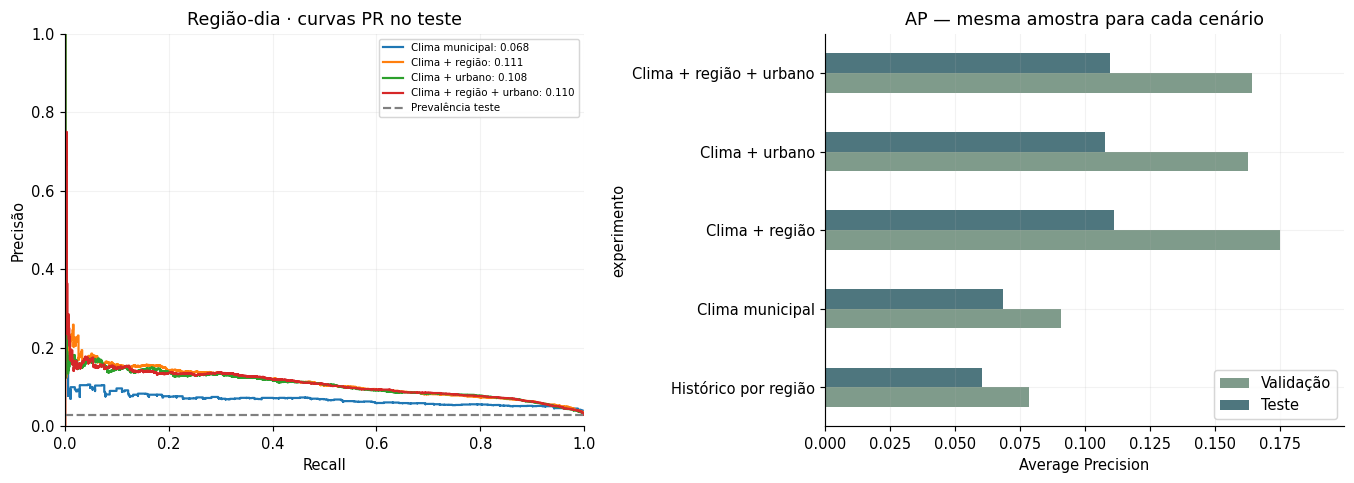

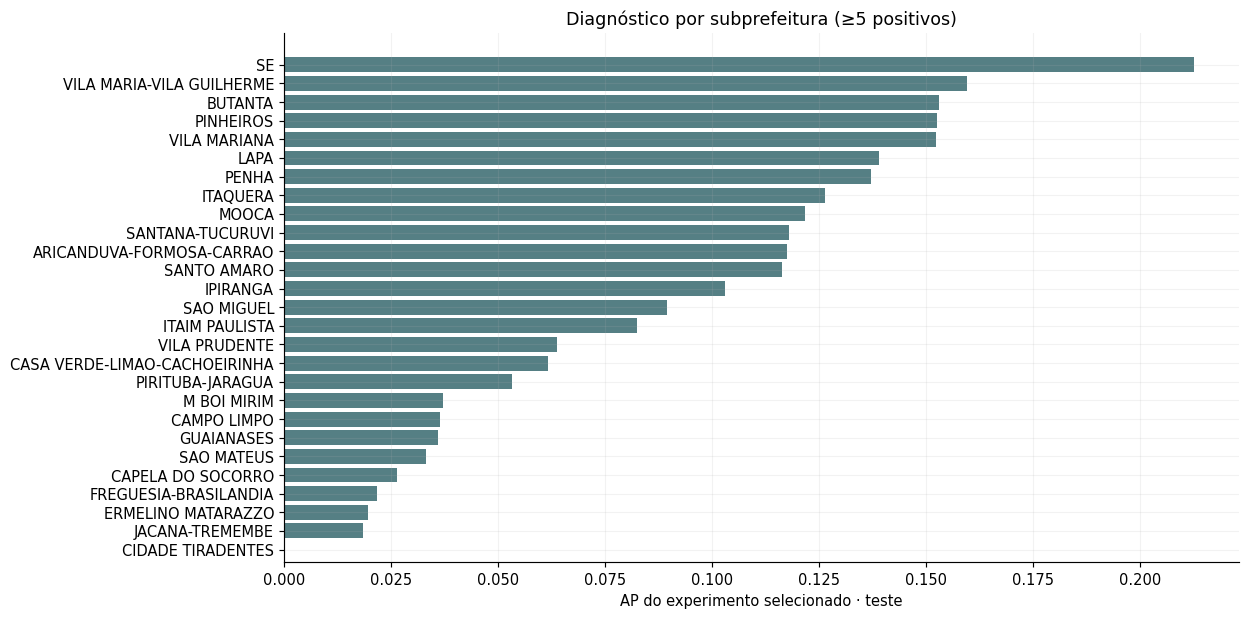

In [19]:
fig,axes=plt.subplots(1,2,figsize=(13,4.7))
for nome,p in test_probs.items():
    if nome=='Histórico por região':continue
    prec,rec,_=precision_recall_curve(te.alvo_regiao_amanha,p)
    axes[0].step(rec,prec,where='post',label=f'{nome}: {resultado_reg_teste.at[nome,"AP"]:.3f}')
axes[0].axhline(te.alvo_regiao_amanha.mean(),ls='--',color='gray',label='Prevalência teste')
axes[0].set(xlabel='Recall',ylabel='Precisão',title='Região-dia · curvas PR no teste',xlim=(0,1),ylim=(0,1))
axes[0].legend(fontsize=7)
baseplot=resultado_reg_val[['AP']].rename(columns={'AP':'Validação'}).join(
    resultado_reg_teste[['AP']].rename(columns={'AP':'Teste'}))
baseplot.plot(kind='barh',ax=axes[1],color=['#7f9b8b','#4e767e'])
axes[1].set(title='AP — mesma amostra para cada cenário',xlabel='Average Precision',xlim=(0,max(.07,baseplot.max().max()*1.14)))
axes[1].legend()
figura('06_curvas_PR_e_ablacao')
fig,ax=plt.subplots(figsize=(12,6))
regioes_plot=por_regiao.sort_values('AP',na_position='first')
ax.barh(regioes_plot.nome_subprefeitura,regioes_plot.AP,color='#557f84')
ax.set(xlabel='AP do experimento selecionado · teste',title='Diagnóstico por subprefeitura (≥5 positivos)')
figura('07_desempenho_regional')

## 3E · Separar capacidade preditiva de interpretação de atributos

Como cada subprefeitura possui uma única linha de vegetação/drenagem para todos os anos, **não existe variação temporal desses atributos dentro da região** nos arquivos atuais. Logo, não podemos estimar quanto uma intervenção modificaria o risco. Além disso, a identidade da subprefeitura pode absorver o mesmo padrão espacial que os atributos medidos.

A tabela abaixo calcula apenas as **diferenças descritivas de AP na validação**, controlando por período, algoritmo e amostra. Ganhos negativos também devem ser relatados. As diferenças entre cenários não são testes de significância estatística.

In [20]:
a=resultado_reg_val['AP']
ablacoes=pd.DataFrame([
 {'comparacao':'Adicionar atributos urbanos sem identificar região',
  'AP_base_validacao':a['Clima municipal'],'AP_expandido_validacao':a['Clima + urbano'],
  'delta_AP_validacao':a['Clima + urbano']-a['Clima municipal']},
 {'comparacao':'Adicionar identidade regional ao clima',
  'AP_base_validacao':a['Clima municipal'],'AP_expandido_validacao':a['Clima + região'],
  'delta_AP_validacao':a['Clima + região']-a['Clima municipal']},
 {'comparacao':'Adicionar urbanos além da identidade regional',
  'AP_base_validacao':a['Clima + região'],'AP_expandido_validacao':a['Clima + região + urbano'],
  'delta_AP_validacao':a['Clima + região + urbano']-a['Clima + região']},
])
display(ablacoes.round(4))
ablacoes.to_csv(SAIDA/'ablacoes_validacao.csv',index=False,encoding='utf-8-sig')
# Interpretação: queda/ganho na AP reflete informação preditiva retrospectiva,
# não ação causal de drenagem ou vegetação.

,comparacao,AP_base_validacao,AP_expandido_validacao,delta_AP_validacao
0,Adicionar atributos urbanos sem identificar re...,0.0907,0.1625,0.0718
1,Adicionar identidade regional ao clima,0.0907,0.1751,0.0844
2,Adicionar urbanos além da identidade regional,0.1751,0.1643,-0.0108


### 3E.1 · Sensibilidade meteorológica por subprefeitura (validação)

Um diagnóstico complementar à ablação é verificar quanto a **AP por região na validação** se altera ao permutar, separadamente, as variáveis de chuva municipal do dia `t` e do acumulado de 7 dias. Isso é calculado somente para regiões com pelo menos 10 registros positivos na validação, com repetições e semente fixa. Quando as variáveis são correlacionadas, a importância individual pode ser compartilhada, e a permutação quebra combinações meteorológicas reais: **não é efeito físico nem causal**. Vegetação/drenagem não recebem permutação *dentro da região*, porque seus valores são constantes na região; sua contribuição só pode ser estudada como associação **entre** regiões.

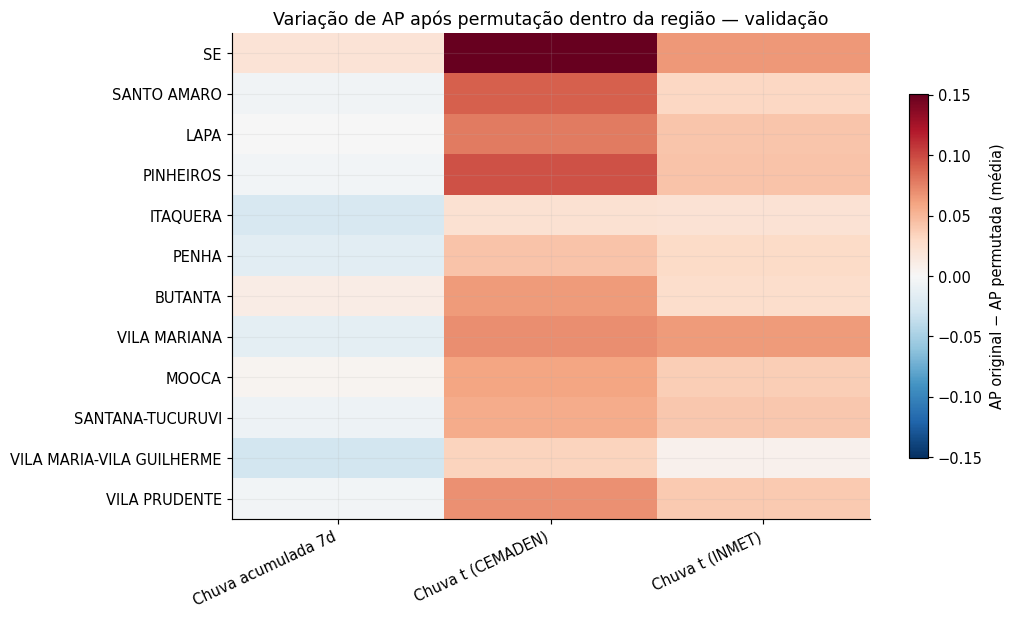

Regiões com >=10 positivos na validação: 23


,codigo_subprefeitura,positivos_validacao,variavel,AP_original,queda_AP_media,desvio_queda_AP,nome_subprefeitura
22,09,95,cemaden_precip_acc7d,0.342,0.021,0.017,SE
23,09,95,sp_precip_mm,0.342,0.066,0.017,SE
21,09,95,cemaden_precip_idw_mm,0.342,0.151,0.008,SE
36,14,69,cemaden_precip_idw_mm,0.260,0.090,0.018,SANTO AMARO
38,14,69,sp_precip_mm,0.260,0.031,0.002,SANTO AMARO
37,14,69,cemaden_precip_acc7d,0.260,-0.005,0.018,SANTO AMARO
19,08,56,cemaden_precip_acc7d,0.236,-0.001,0.006,LAPA
20,08,56,sp_precip_mm,0.236,0.042,0.011,LAPA
18,08,56,cemaden_precip_idw_mm,0.236,0.078,0.013,LAPA
28,11,55,cemaden_precip_acc7d,0.214,-0.004,0.005,PINHEIROS


In [21]:
rng = np.random.default_rng(SEMENTE)
variaveis_teste = ['cemaden_precip_idw_mm','cemaden_precip_acc7d','sp_precip_mm']
linhas_imp=[]
for codigo,g in va.groupby('codigo_subprefeitura',sort=True):
    positivos=int(g.alvo_regiao_amanha.sum())
    if positivos<10: continue
    x=g[CENARIOS[selecionado]].copy()
    y=g.alvo_regiao_amanha.to_numpy()
    ap_original=average_precision_score(y,models[selecionado].predict_proba(x)[:,1])
    for var in variaveis_teste:
        mudancas=[]
        for _ in range(4):
            xp=x.copy()
            xp[var] = rng.permutation(x[var].to_numpy())
            ap_nova=average_precision_score(y,models[selecionado].predict_proba(xp)[:,1])
            mudancas.append(ap_original-ap_nova)
        linhas_imp.append({'codigo_subprefeitura':codigo,'positivos_validacao':positivos,
            'variavel':var,'AP_original':ap_original,'queda_AP_media':np.mean(mudancas),
            'desvio_queda_AP':np.std(mudancas,ddof=1)})
impactos_reg = pd.DataFrame(linhas_imp).merge(
    urbano[['codigo_subprefeitura','nome_subprefeitura']],on='codigo_subprefeitura')
impactos_reg.to_csv(SAIDA/'sensibilidade_chuva_por_subprefeitura_validacao.csv',
                    index=False,encoding='utf-8-sig')
mais_eventos=(impactos_reg.groupby('nome_subprefeitura').positivos_validacao.first()
                 .nlargest(12).index)
quadro=impactos_reg.loc[impactos_reg.nome_subprefeitura.isin(mais_eventos)].pivot(
    index='nome_subprefeitura',columns='variavel',values='queda_AP_media')
quadro=quadro.loc[mais_eventos]
fig,ax=plt.subplots(figsize=(10,6))
lim=np.nanmax(np.abs(quadro.values))
im=ax.imshow(quadro,cmap='RdBu_r',vmin=-lim,vmax=lim,aspect='auto')
ax.set(yticks=np.arange(len(quadro)),yticklabels=quadro.index,
       xticks=np.arange(len(quadro.columns)),xticklabels=[{'cemaden_precip_idw_mm':'Chuva t (CEMADEN)',
       'cemaden_precip_acc7d':'Chuva acumulada 7d','sp_precip_mm':'Chuva t (INMET)'}[k]
            for k in quadro.columns],
       title='Variação de AP após permutação dentro da região — validação')
plt.setp(ax.get_xticklabels(),rotation=25,ha='right')
fig.colorbar(im,ax=ax,label='AP original − AP permutada (média)',shrink=.75)
figura('08_sensibilidade_chuva_por_subprefeitura')
print('Regiões com >=10 positivos na validação:',impactos_reg.codigo_subprefeitura.nunique())
display(impactos_reg.sort_values('positivos_validacao',ascending=False).head(12).round(3))

## 3F · O que ainda não cabe neste modelo: previsões arquivadas e chuva regionalizada

**Open-Meteo Previous Runs:** 2024–maio/2026. O arquivo contém chuvas previstas para o dia-alvo em D-1, D-2 e D-3, mas alguns totais diários estão ausentes. Não é válido misturar previsões arquivadas de 2024+ com reanálise histórica de 2015–2023 como se todas estivessem disponíveis em D-1. Também não se deve usar `precipitation_error_dayN` como preditor: depende de conhecer o valor de referência após o dia previsto.

**Chuva CEMADEN por região:** as 95 coordenadas estão disponíveis, mas não os arquivos de observação diária por estação. Para produzir `chuva_regiao_t`, precisamos importar `data/outputs/cemaden_raw` ou gerar um CSV confiável `cod_estacao,date,precip_total_mm` *após as duas exclusões*. Depois, calcular IDW local por estação/dia, controlar cobertura e refazer **todos** os cenários com essa mesma nova variável. A série municipal atual jamais substitui uma série regional verificada.

In [22]:
cobertura_prev = pd.DataFrame([{'horizonte':f'D-{n}',
 'dias_arquivo':len(previsoes_arquivo),
 'dias_com_previsao':int(previsoes_arquivo[f'precipitation_previous_day{n}'].notna().sum()),
 'dias_sem_previsao':int(previsoes_arquivo[f'precipitation_previous_day{n}'].isna().sum()),
 'inicio':previsoes_arquivo.date.min().date(), 'fim':previsoes_arquivo.date.max().date()}
 for n in [1,2,3]])
display(cobertura_prev)
cobertura_prev.to_csv(SAIDA/'cobertura_previous_runs.csv',index=False,encoding='utf-8-sig')

,horizonte,dias_arquivo,dias_com_previsao,dias_sem_previsao,inicio,fim
0,D-1,882,863,19,2024-01-01,2026-05-31
1,D-2,882,862,20,2024-01-01,2026-05-31
2,D-3,882,861,21,2024-01-01,2026-05-31


# Conclusão e próximos testes

1. A integração do CGE com o GeoSampa permite representar os **32 territórios** em uma grade região-dia, preservando as ocorrências e o calendário.
2. Os atributos de vegetação/drenagem descrevem **diferenças espaciais de um retrato cadastral**, e não a evolução urbana diária de 2015–2026. A análise ecológica deve ser apresentada como associação, não impacto de intervenção.
3. A modelagem compara um baseline municipal e versões regionais com ablações controladas. As métricas e seus resultados positivos ou negativos ficam salvos e devem ser discutidos com atenção à baixa prevalência por região.
4. Os próximos experimentos metodologicamente distintos são: **chuva diária IDW por subprefeitura** a partir dos arquivos estação-dia; **previsão genuína D-1** com arquivo Previous Runs no período comum; **análise de versões históricas das camadas urbanas**; validação de latências e de dias com cobertura do CGE confirmada; incerteza temporal via blocos.

**Como citar os resultados:** identifique sempre o período, a unidade `região-dia` ou `município-dia`, o alvo `registro CGE`, a prevalência do teste, a data das camadas territoriais, e se as variáveis são conhecidas *antes* da previsão ou só no retrato retrospectivo.

In [23]:
# Manifesto simples de reprodutibilidade: versões, parâmetros, recortes, hashes e resultado.
fontes=[DADOS/n for n in ['dataset_final_integrado.csv','final_data.csv',
       'cemaden_sp_diario.csv','consolidated_dataset.csv','open_meteo_sp.csv',
       'open_meteo_previous_runs_sp.csv','cemaden_estacoes.csv','stations_metadata.csv']]
fontes += [GEO/n for n in ['cge_subprefeitura_dia.csv','indicadores_subprefeituras.csv',
                          'subprefeituras_tratadas.gpkg','auditoria.json']]
manifesto={
 'titulo':'EDA + baseline municipal D+1 + análise retrospectiva regional',
 'fonte_sha256':{p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in fontes},
 'python':platform.python_version(),'pandas':pd.__version__,
 'semente':SEMENTE,'base_historica':periodo(municipio),
 'vegetacao_ano_voo':DATA_VEGETACAO,'drenagem_atualizacao':DATA_DRENAGEM,
 'alvo':'registro CGE por dia-região no dia seguinte',
 'alerta':'Snapshot urbano 2026 NÃO comprovado como histórico 2015-2026.',
 'meteo':'CEMADEN e INMET consolidados em escala municipal; chuva regional ainda pendente.',
 'hiperparametros_regionais':modelo_regional().get_params(),
 'colunas':{'clima':CLIMA,'urbanas':URB,'regioes':REG},
 'cortes':resumo_cortes.astype(str).to_dict(orient='records'),
 'experimento_municipal_selecionado_na_validacao':selecionado_municipal,
 'experimento_selecionado_so_validacao':selecionado,
 'limiar_congelado':lims[selecionado],
 'AP_validacao_selecionado':float(resultado_reg_val.at[selecionado,'AP']),
 'AP_teste_selecionado':float(resultado_reg_teste.at[selecionado,'AP']),
 'nota':'O teste é retrospectivo; não houve retreino após a validação.'}
(SAIDA/'manifesto.json').write_text(json.dumps(manifesto,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
print('Experimento regional escolhido na validação:',selecionado)
print(f"AP validação = {resultado_reg_val.at[selecionado,'AP']:.3f}; "
      f"AP teste = {resultado_reg_teste.at[selecionado,'AP']:.3f}; "
      f"prevalência teste = {te.alvo_regiao_amanha.mean():.3%}")
print('Arquivos exportados para:',SAIDA)

Experimento regional escolhido na validação: Clima + região
AP validação = 0.175; AP teste = 0.111; prevalência teste = 3.001%
Arquivos exportados para: C:\Users\rickn\OneDrive\Documentos\GitHub\Projeto_Previsão_Alagamentos_TCC_2026\data\outputs\modelagem\analise_integrada_subprefeituras


# 4 · Nova etapa: chuva real regionalizada e modelo D+1

**Atualização da análise integrada.** As seções 1–3 acima descrevem o experimento anterior, que repetia a chuva municipal nas 32 subprefeituras. Os resultados já exibidos nas seções anteriores **não são resultados da regionalização**. Esta seção é executada no seu projeto local, a partir dos arquivos brutos reais em `data/outputs/cemaden_raw/` ou de um CSV pré-exportado com uma linha por estação-dia.

**Pergunta:** ao estimar precipitação distinta para cada região, o modelo reconhece mais registros de alagamento em `t+1` do que utilizando somente a chuva municipal? A comparação usa o MESMO conjunto de observações elegíveis, divisão temporal, algoritmo e hiperparâmetros.

A interpolação espacial utiliza pontos representativos dos polígonos GeoSampa em EPSG:31983, IDW com potência 2, as cinco estações disponíveis mais próximas até 30 km e mínimo de duas. É uma estimativa pontual — não a chuva média real de todo o território. Sem duas estações válidas no dia, o valor local fica ausente. As duas exclusões estação-dia da Boa Esperança continuam válidas.

**Atenção:** as séries locais usadas aqui são observações de `t`. O modelo prevê registro em `t+1` *com base no que ocorreu até o fim de t*; não utiliza chuva observada em `t+1`, nem substitui um experimento futuro com previsões meteorológicas efetivamente arquivadas. Vegetação 2017 e drenagem 2026 são exposições estáticas **ex post**.

In [25]:
# Este código requer, ao lado do ETL original, o novo script incluído no pacote.
import importlib.util
from pathlib import Path

CANDIDATOS_SCRIPT = [
    RAIZ/'scripts/etl/03_regionalizar_cemaden_e_modelar.py',
    RAIZ/'03_regionalizar_cemaden_e_modelar.py',
    Path.cwd()/'03_regionalizar_cemaden_e_modelar.py',
]
NOVO_SCRIPT = next((p for p in CANDIDATOS_SCRIPT if p.exists()),None)
if NOVO_SCRIPT is None:
    raise FileNotFoundError('Copie 03_regionalizar_cemaden_e_modelar.py para scripts/etl/.')
spec = importlib.util.spec_from_file_location('regionalizar_cemaden_tcc', NOVO_SCRIPT)
regional = importlib.util.module_from_spec(spec)
spec.loader.exec_module(regional)
print('Script regional:', NOVO_SCRIPT)

Script regional: C:\Users\rickn\OneDrive\Documentos\GitHub\Projeto_Previsão_Alagamentos_TCC_2026\scripts\etl\03_regionalizar_cemaden_e_modelar.py


## 4.1 · Suporte espacial da rede existente

A distribuição geográfica pode ser calculada com os **metadados das 95 estações já anexados**, independentemente das leituras horárias. Este quadro responde apenas se há pluviômetros próximos; **não** responde se estavam operantes em determinado dia. A cobertura temporal real será calculada depois da leitura das séries brutas.

In [26]:
regioes_pontos, matriz_distancias = regional.localizacoes(cemaden_estacoes, limites)
suporte_espacial = pd.DataFrame({
    'codigo_subprefeitura': regioes_pontos.codigo_subprefeitura,
    'nome_subprefeitura': regioes_pontos.nome_subprefeitura,
    'estacoes_ate_30km': (matriz_distancias<=30).sum(axis=1),
    'distancia_estacao_mais_proxima_km': matriz_distancias.min(axis=1),
    'distancia_5a_mais_proxima_km': np.sort(matriz_distancias,axis=1)[:,4],
}).sort_values('estacoes_ate_30km')
display(suporte_espacial.head(10).round(2))
print('Menor número de estações no raio de 30km:',suporte_espacial.estacoes_ate_30km.min())
print('ATENÇÃO: metadados de proximidade não garantem cobertura diária.')
suporte_espacial.to_csv(SAIDA/'suporte_espacial_idw_32_subprefeituras.csv',index=False,encoding='utf-8-sig')

,codigo_subprefeitura,nome_subprefeitura,estacoes_ate_30km,distancia_estacao_mais_proxima_km,distancia_5a_mais_proxima_km
19,20,PARELHEIROS,26,5.69,14.73
0,01,PERUS-ANHANGUERA,57,1.38,8.35
23,24,ITAIM PAULISTA,57,1.21,5.49
30,31,CIDADE TIRADENTES,61,1.04,3.68
27,28,GUAIANASES,61,0.60,4.05
22,23,SAO MIGUEL,66,0.38,3.77
18,19,CAPELA DO SOCORRO,66,1.53,5.15
17,18,M BOI MIRIM,69,0.31,4.97
29,30,SAO MATEUS,71,1.13,3.95
1,02,PIRITUBA-JARAGUA,71,2.49,4.04


Menor número de estações no raio de 30km: 26
ATENÇÃO: metadados de proximidade não garantem cobertura diária.


## 4.2 · Processamento das séries reais e auditoria

Ao executar em seu computador, `executar()` procura `data/outputs/datasets/cemaden_estacao_dia.csv`. Se não houver, lê os arquivos brutos já existentes em `data/outputs/cemaden_raw/`, aplica o parser do ETL original, agrega por estação-dia e escreve um intermediário reutilizável. Casos de sobreposição entre arquivos com totais conflitantes **interrompem a execução para revisão**, e não são somados nem escolhidos silenciosamente.

Todas as saídas ficam em `data/outputs/modelagem/chuva_regional_subprefeituras/`. Os CSVs históricos existentes **não são modificados**.

In [27]:
# No ambiente de anexos, não há arquivos RAW individuais. A verificação abaixo
# impede que valores inventados sejam apresentados como resultado do modelo.
entrada_estacao_dia = DADOS/'cemaden_estacao_dia.csv'
entrada_raw = (RAIZ/'data/outputs/cemaden_raw' if not ANEXO else RAIZ/'cemaden_raw')
TEM_DADOS_REAIS = entrada_estacao_dia.exists() or (
    entrada_raw.exists() and any(entrada_raw.rglob('*.csv')))
print('Observações individuais presentes?',TEM_DADOS_REAIS)
if not TEM_DADOS_REAIS:
    print('ETAPA PENDENTE: execute no repositório local, onde está a pasta cemaden_raw. '
          'Os resultados exibidos antes nesta análise são do modelo com chuva MUNICIPAL.')

Observações individuais presentes? True


In [28]:
if TEM_DADOS_REAIS:
    manifesto_chuva_regional, pasta_resultados_chuva = regional.executar(RAIZ)
    print('Processamento completo:',pasta_resultados_chuva)
else:
    manifesto_chuva_regional = None
    pasta_resultados_chuva = None

Chuva por subprefeitura calculada: 133408 linhas; fonte: séries horárias/10min originais agregadas por estação-dia
Cobertura por subprefeitura (%): 99.59 a 99.9
VALIDAÇÃO
                                     AP  precisao  recall
experimento                                             
Municipal + região (referência)  0.157     0.203   0.333
Chuva local + região             0.148     0.164   0.409
Municipal + local + região       0.157     0.198   0.366
Chuva local + urbano             0.149     0.163   0.437
Chuva local + região + urbano    0.149     0.178   0.371
TESTE reservado
                                     AP  precisao  recall  prevalencia
experimento                                                          
Municipal + região (referência)  0.110     0.134   0.279         0.03
Chuva local + região             0.126     0.133   0.381         0.03
Municipal + local + região       0.110     0.129   0.301         0.03
Chuva local + urbano             0.126     0.131   0.413      

## 4.3 · Comparação com amostra comum e interpretação

Cinco variantes de `HistGradientBoostingClassifier` são avaliadas. O controle principal é **clima municipal + identidade regional**; as demais adicionam/substituem os totais municipais pela chuva local e incluem ou não vegetação, densidade de drenagem e área. A seleção de experimento e limiar é feita na validação **2022–2023**; o teste **2024–maio/2026** fica reservado para relatório final.

A comparação válida é entre a referência municipal **recalculada sobre exatamente os mesmos dias-região cobertos por chuva local** e os novos experimentos, **não** simplesmente entre a nova AP e 0,111 do notebook anterior, que pode abranger dias diferentes.

Uma queda da AP ao permutar chuva por região na validação é um diagnóstico **associativo de dependência preditiva**, não um efeito causal da chuva nem da vegetação ou da rede de drenagem.

VALIDAÇÃO (decisão):


,experimento,prevalencia,AP,precisao,recall,F1,limiar
0,Municipal + região (referência),0.035,0.157,0.203,0.333,0.252,0.13
1,Chuva local + região,0.035,0.148,0.164,0.409,0.234,0.11
2,Municipal + local + região,0.035,0.157,0.198,0.366,0.257,0.12
3,Chuva local + urbano,0.035,0.149,0.163,0.437,0.238,0.11
4,Chuva local + região + urbano,0.035,0.149,0.178,0.371,0.240,0.13


TESTE reservado (avaliação final; período 2026 incompleto):


,experimento,prevalencia,AP,precisao,recall,F1,limiar
0,Municipal + região (referência),0.03,0.110,0.134,0.279,0.181,0.13
1,Chuva local + região,0.03,0.126,0.133,0.381,0.197,0.11
2,Municipal + local + região,0.03,0.110,0.129,0.301,0.181,0.12
3,Chuva local + urbano,0.03,0.126,0.131,0.413,0.199,0.11
4,Chuva local + região + urbano,0.03,0.126,0.139,0.329,0.196,0.13


SUPORTE DIÁRIO DE CHUVA REGIONAL:


,nome_subprefeitura,estacoes_no_raio,n_estacoes_mediana,pct_dias_cobertos
19,PARELHEIROS,26,5.0,99.59
17,M BOI MIRIM,69,5.0,99.83
18,CAPELA DO SOCORRO,66,5.0,99.83
0,PERUS-ANHANGUERA,57,5.0,99.86
23,ITAIM PAULISTA,57,5.0,99.86
30,CIDADE TIRADENTES,61,5.0,99.86
27,GUAIANASES,61,5.0,99.86
1,PIRITUBA-JARAGUA,71,5.0,99.88
20,PENHA,88,5.0,99.88
21,ERMELINO MATARAZZO,76,5.0,99.88


Regiões com menos de 5 positivos no teste: 6


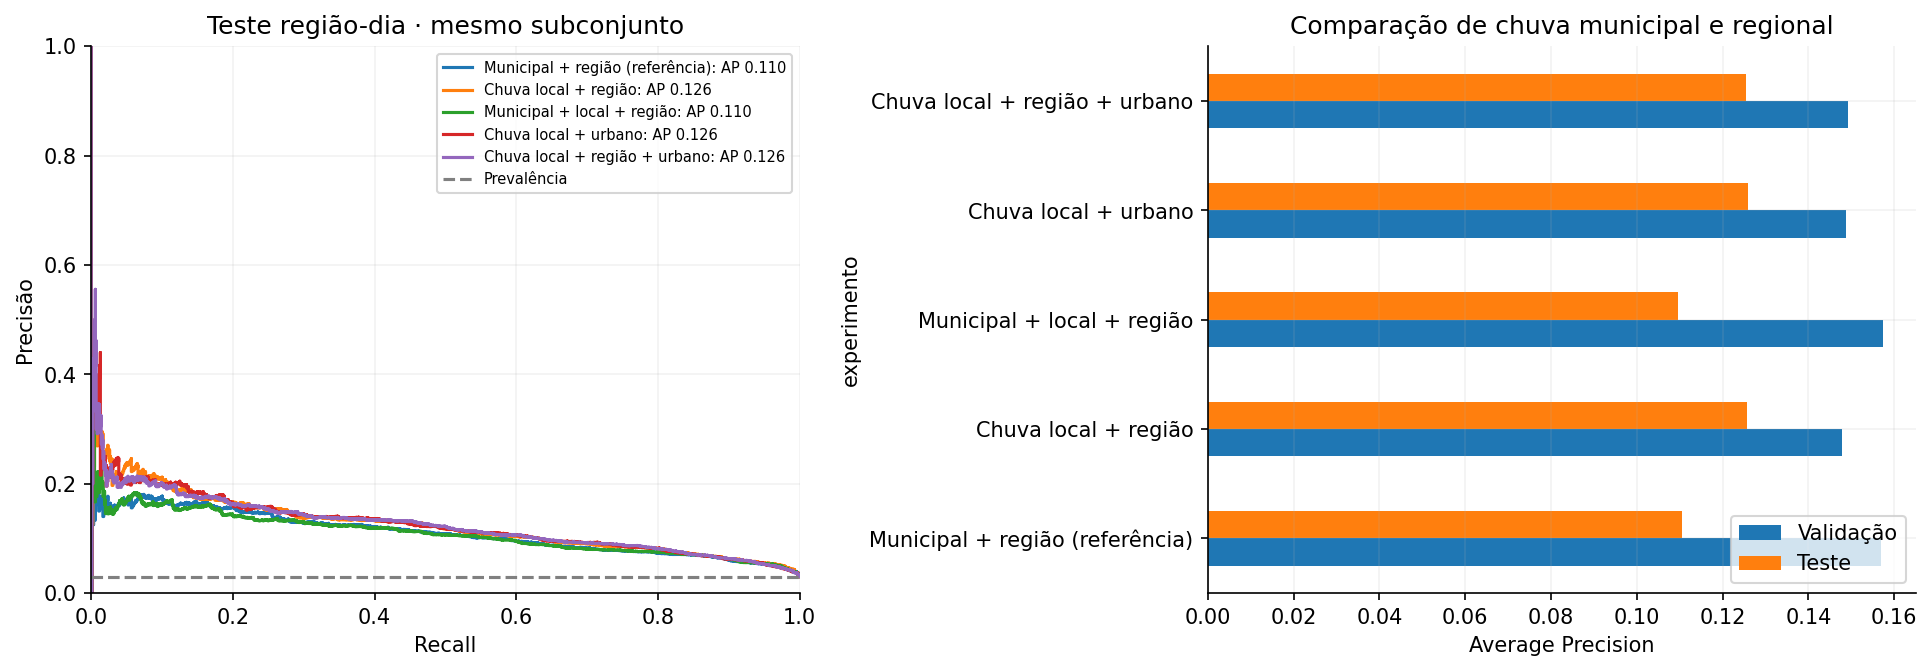

In [29]:
if pasta_resultados_chuva is not None:
    m_valid = pd.read_csv(pasta_resultados_chuva/'metricas_validacao_chuva_regional.csv')
    m_teste = pd.read_csv(pasta_resultados_chuva/'metricas_teste_chuva_regional.csv')
    qualidade = pd.read_csv(pasta_resultados_chuva/'cobertura_chuva_por_subprefeitura.csv',
              dtype={'codigo_subprefeitura':str})
    reg_teste = pd.read_csv(pasta_resultados_chuva/'metricas_por_subprefeitura.csv',
              dtype={'codigo_subprefeitura':str})
    print('VALIDAÇÃO (decisão):')
    display(m_valid[['experimento','prevalencia','AP','precisao','recall','F1','limiar']].round(3))
    print('TESTE reservado (avaliação final; período 2026 incompleto):')
    display(m_teste[['experimento','prevalencia','AP','precisao','recall','F1','limiar']].round(3))
    print('SUPORTE DIÁRIO DE CHUVA REGIONAL:')
    display(qualidade[['nome_subprefeitura','estacoes_no_raio','n_estacoes_mediana',
             'pct_dias_cobertos']].sort_values('pct_dias_cobertos').head(10).round(2))
    print('Regiões com menos de 5 positivos no teste:',
          int((reg_teste.positivos<5).sum()))
    from IPython.display import Image
    display(Image(filename=str(pasta_resultados_chuva/'comparacao_modelos_chuva_regional.png')))
else:
    print('Ainda não existem métricas da chuva regionalizada: faltam os arquivos individuais do CEMADEN.')

## 4.4 · Leituras para incorporar ao TCC depois da execução

- **Desempenho:** relatar AP, prevalência, precisão, recall e fração de alertas lado a lado, sem chamar prevalência de acurácia.
- **Regionalização:** relatar cobertura por subprefeitura, distância e número de estações utilizadas; discutir possível viés nas regiões com menor disponibilidade.
- **Variáveis urbanas:** apresentar duas ablações distintas (com e sem identidade regional); manter ressalva de representatividade histórica (vegetação de 2017, drenagem cadastral de 2026).
- **Validade operacional:** a previsão para D+1 é baseada em chuva de D0 já observada. Modelos que incorporarem previsão meteorológica de amanhã precisarão de outro experimento com arquivos de previsões arquivadas.
- **Desfecho:** ausência de registro no CGE não comprova ausência física de alagamento. A qualidade da coleta condiciona todas as métricas.